# Analysing Booking trends in the Hospitality Industry

## Business Introduction
A predictive model to determine the booking status of a customer
Hotel haven is a hotel chain with multiple locations. The hotel offers a wide range of services including various types of rooms, meal plans an dparking options.
Hotel Haven has been facing challenges in predicting customer cancellations, which impacts thier ability to manage resources effectively. The hoel wants to better understand their booking patterns and create strategies that could improve customer retention and reduce cancellations.

## Problem Statement 
The hotel struggle swith high cancellation rates, leading to lost revenue and inefficient resource allocation. The existing system doe snot provide sufficient insights into why customers cancel their bookings. The hotel management seeks to predict cancelations based on booking data to improve operational efficiency and customer retention. 

## Rationale for the project
**Understanding Cancellations**
Analysing booking patterns help uncover the underlying reasons why customers cancel their bookings.

**Identifying Key Factors**
By examining variables like lead timer, room type, market segment and price, the project alows the identification of specific factors that influence customers decision to either cancel or keep their bookings.

**Optimising customer satisfaction**
By minimising cancellations, the hotel can ensure better resource allocation and improved guest experience. customers who are less likely to cancel will contribute to smoother operations and increased satisfaction. 

## Deliverables 
- Data Cleaning
- Data Exploration
- Comprehensive Data Analysis
- Feature Engineering and Model Development
- Model Evaluation and Finetuning 
- Jupyter Notebook and Powerpoint Slides

## Data Dictionary

Booking_ID - Unique identifier for each booking String

number of adults - Number of adults in the booking Integer

number of children - Number of children in the booking Integer

number of weekend nights - Number of weekend nights included in the booking Integer

number of week - nights Number of week nights included in the booking Integer

type of meal - Meal plan selection (e.g., Meal Plan 1, Not Selected) Categorical

car parking space - Whether the booking includes parking (0: No, 1: Yes) Binary

room type -  Type of room booked (e.g., Room_Type 1, Room_Type 2) Categorical

lead time - Time between the reservation and check-in date Integer

market segment type - Booking channel (e.g., Online, Offline) Categorical

repeated - Whether the booking is from a repeat customer (0: No, 1: Yes) Binary

P-C - Customer profile type indicator (0: Not Customer, 1: Customer) Binary

P-not-C - Non-customer profile type indicator (0: Not Non-Customer, 1:
Non-Customer) Binary.

average price - Average price of the booking Float

special requests - Number of special requests made by the customer Integer

date of reservation - Date the reservation was made Date

booking status -  Status of the booking (e.g., Canceled, Not Canceled) Categorical


In [1]:
print("Hello")


Hello


In [2]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


## Load the dataset

In [3]:
data = pd.read_csv('/Users/kabirmuhammad/Desktop/10Alytics/jupyter_notebook/Hotel_Haven_ML_Project/booking - booking.csv')

In [4]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [6]:
data.shape

(36285, 17)

## Data Cleaning and Exploration

In [7]:
# See the statistics of numerical 
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## Handle missing values
Visualisation for missing values

In [8]:
# Check for missing values
data.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

<Axes: >

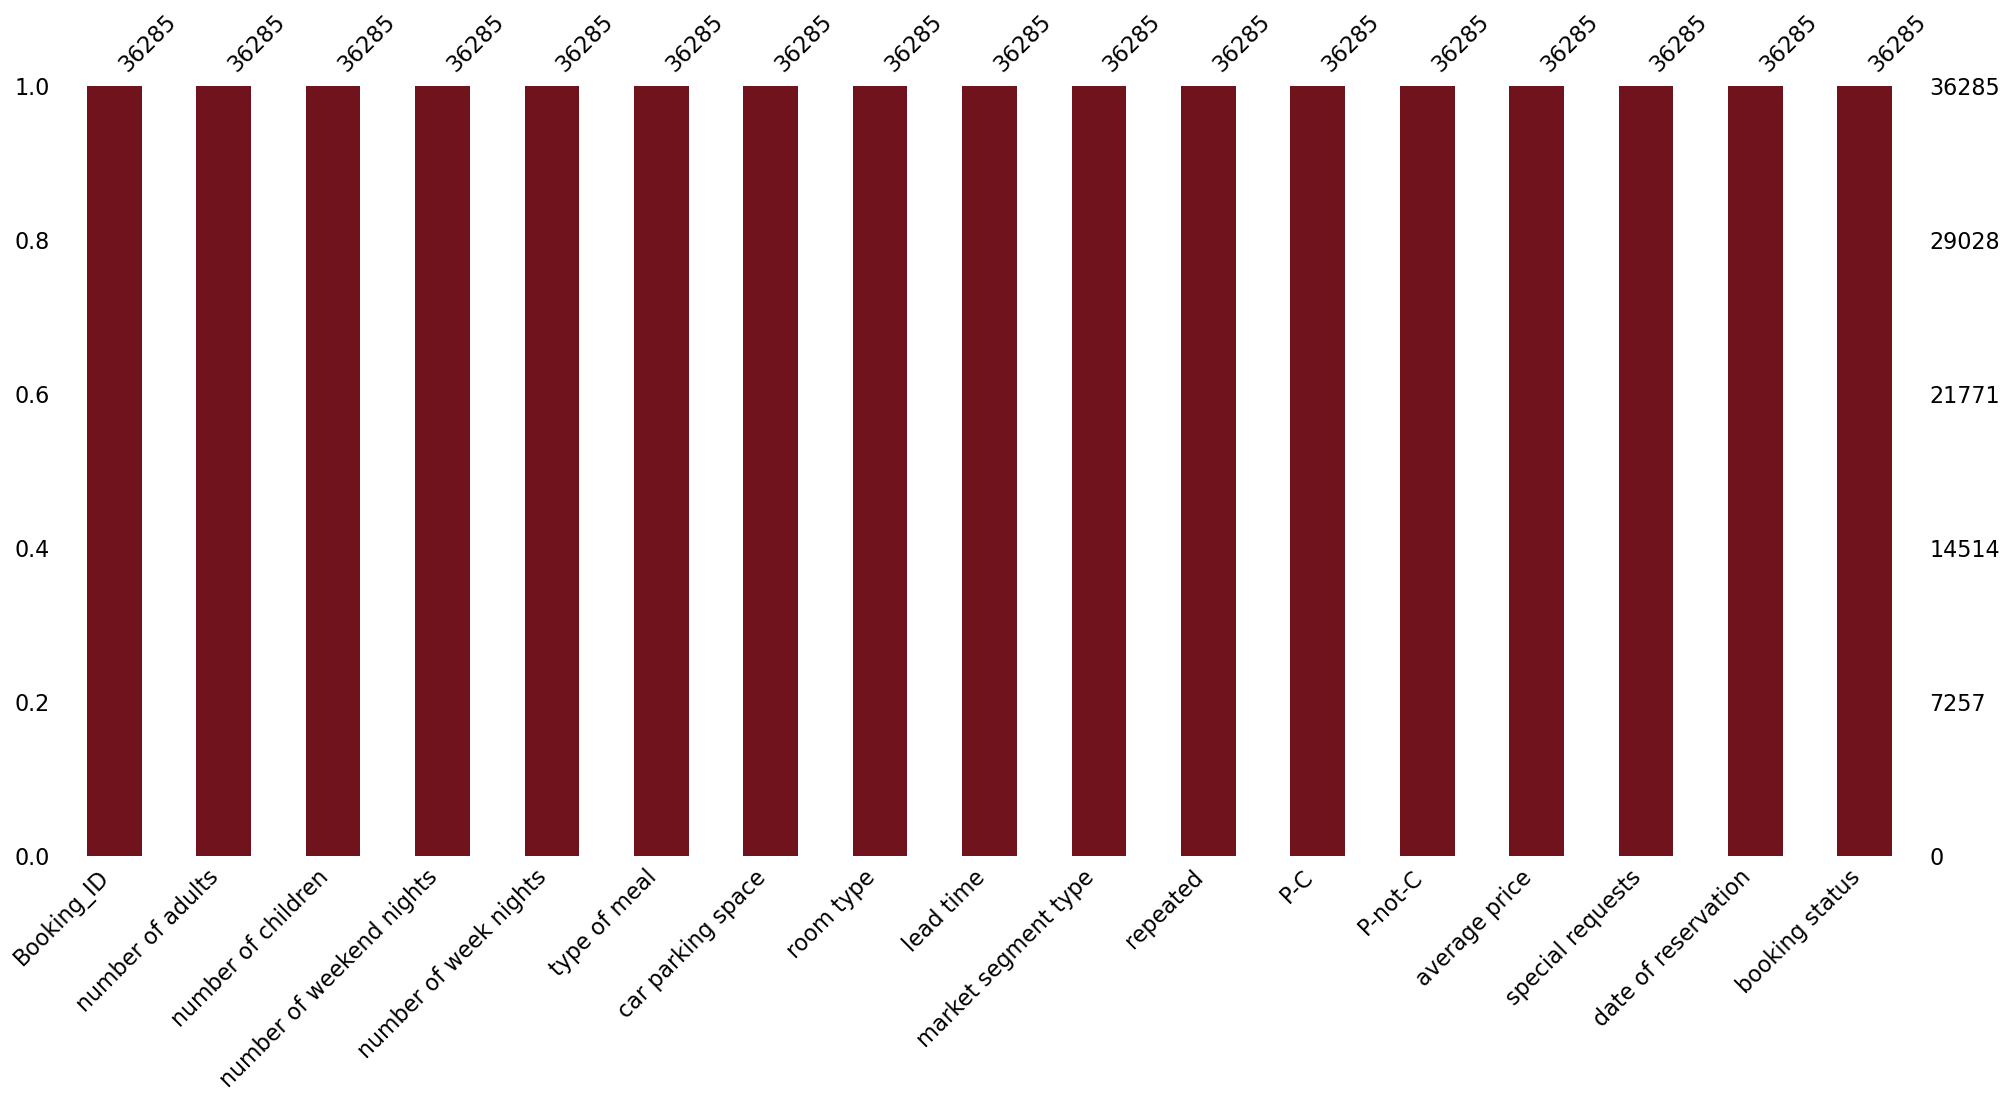

In [9]:
# Visualisation of missing data for easy communication
msno.bar(data, color='#70131D')

We have confirmed that there arent any missing values.

## Handle duplicate data
Detect duplicated data and remove if any

In [10]:
data.duplicated().sum()

np.int64(0)

We can also confirm that there arent any duplicated data

PLAN 

Data Cleaning and Exploration - 
- Cleaning, 
- missing values,
- Outliers, 
- Check and Change necessary data type
- Univariate, Bivariate and Multivariate analysis
- Data Analysis: Narrate Observation
  
ML 
- Clean data for ML, Handle outliers
- Encode Categorical variables
- Scale Numerical values
- Check and handle class imbalance of target variable: Oversampling
- Data Splitting
- Model Selection
- Hyper parameter tuning and
- Model Evaluation
- Save the model 

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [12]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [13]:
# Correct the data types datetime specifically
data['date of reservation'] = pd.to_datetime(data['date of reservation'], errors = 'coerce', dayfirst=True, yearfirst=True, format="mixed")

In [14]:
# Extract the Year, Month, Quarter - create new columns(features)(feature engineering)
data['year'] = data["date of reservation"].dt.year
data['month'] = data["date of reservation"].dt.month
data['day_of_week'] = data['date of reservation'].dt.dayofweek

In [15]:
data['day_of_week'].unique()

array([ 1.,  0.,  2.,  5.,  6.,  3.,  4., nan])

In [16]:
month_map = {
    1.: 'Jan', 2.: 'Feb', 3.: 'Mar', 4.: 'Apr',
    5.: 'May', 6.: 'Jun', 7.: 'Jul', 8.: 'Aug',
    9.: 'Sep', 10.: 'Oct', 11.: 'Nov', 12.: 'Dec'
}

data['month'] = data['month'].map(month_map).astype('category')

In [17]:
day_map = {
    0.: 'Mon', 1.: 'Tue', 2.: 'Wed',
    3.: 'Thu', 4.: 'Fri', 5.: 'Sat', 6.: 'Sun'
}

data['day_of_week'] = data['day_of_week'].map(day_map).astype('category')

In [18]:
data['year'] = data['year'].astype('category')

In [19]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,year,month,day_of_week
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-02-10,Not_Canceled,2015.0,Feb,Tue
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-06-11,Not_Canceled,2018.0,Jun,Mon
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,Canceled,2018.0,Feb,Wed
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,Canceled,2017.0,May,Sat
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-11-04,Canceled,2018.0,Nov,Sun


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36285 non-null  object        
 1   number of adults          36285 non-null  int64         
 2   number of children        36285 non-null  int64         
 3   number of weekend nights  36285 non-null  int64         
 4   number of week nights     36285 non-null  int64         
 5   type of meal              36285 non-null  object        
 6   car parking space         36285 non-null  int64         
 7   room type                 36285 non-null  object        
 8   lead time                 36285 non-null  int64         
 9   market segment type       36285 non-null  object        
 10  repeated                  36285 non-null  int64         
 11  P-C                       36285 non-null  int64         
 12  P-not-C           

In [21]:
sns.set_theme(style="whitegrid")

sns.set_palette(["#70131D", "#4CAF50"])

In [22]:
unique = data['type of meal'].unique()
unique

array(['Meal Plan 1', 'Not Selected', 'Meal Plan 2', 'Meal Plan 3'],
      dtype=object)

In [23]:
unique = data['room type'].unique()
unique

array(['Room_Type 1', 'Room_Type 4', 'Room_Type 2', 'Room_Type 6',
       'Room_Type 5', 'Room_Type 7', 'Room_Type 3'], dtype=object)

In [24]:
unique = data['market segment type'].unique()
unique

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

In [25]:
unique = data['car parking space'].unique()
unique

array([0, 1])

In [26]:
# Change car parking space to boolean
data['car parking space'] = data['car parking space'].astype(bool)

In [27]:
unique = data['car parking space'].unique()
unique

array([False,  True])

In [28]:
unique = data['P-C'].unique()
unique

array([ 0,  3,  1,  2, 11,  4,  5, 13,  6])

In [29]:
unique = data['P-not-C'].unique()
unique

array([ 0,  5,  1,  3,  4, 12, 19,  2, 15, 17,  7, 20, 16, 50, 13,  6, 14,
       34, 18,  8, 10, 23, 11, 49, 47, 53,  9, 33, 22, 24, 52, 21, 48, 28,
       39, 25, 31, 38, 26, 51, 42, 37, 35, 56, 44, 27, 32, 55, 45, 30, 57,
       46, 54, 43, 58, 41, 29, 40, 36])

In [30]:
unique = data['booking status'].unique()
unique

array(['Not_Canceled', 'Canceled'], dtype=object)

In [31]:
unique = data['repeated'].unique()
unique

array([0, 1])

<Axes: xlabel='P-C', ylabel='count'>

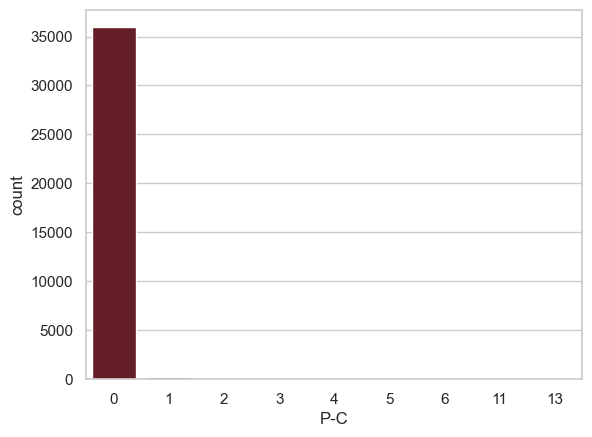

In [32]:
sns.countplot(x="P-C", data=data)

<Axes: xlabel='P-not-C', ylabel='count'>

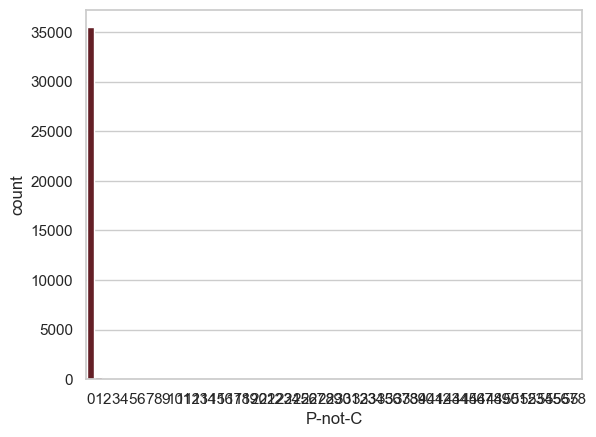

In [33]:
sns.countplot(x="P-not-C", data=data)

## In the data dictionary, our P-C and P-not-C are supposed to be customer profile type indicators which are supposed to be binary.
P-C: 0 for Not Customer and 1 for Customer 
P-not-C: 0 for Not Non Customer and 1 for Non-Customer
Therefore we need to convert these to Binary data type 

In [34]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,year,month,day_of_week
0,INN00001,1,1,2,5,Meal Plan 1,False,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-02-10,Not_Canceled,2015.0,Feb,Tue
1,INN00002,1,0,1,3,Not Selected,False,Room_Type 1,5,Online,0,0,0,106.68,1,2018-06-11,Not_Canceled,2018.0,Jun,Mon
2,INN00003,2,1,1,3,Meal Plan 1,False,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,Canceled,2018.0,Feb,Wed
3,INN00004,1,0,0,2,Meal Plan 1,False,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,Canceled,2017.0,May,Sat
4,INN00005,1,0,1,2,Not Selected,False,Room_Type 1,48,Online,0,0,0,77.00,0,2018-11-04,Canceled,2018.0,Nov,Sun


In [35]:
# Change P-C and P-not-C to boolean
data['P-C'] = data['P-C'].astype(bool)
data['P-not-C'] = data['P-not-C'].astype(bool)

<Axes: xlabel='P-C', ylabel='count'>

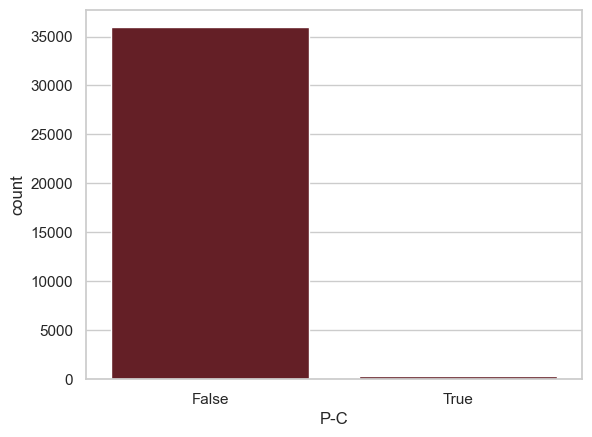

In [36]:
sns.countplot(x="P-C", data=data)

<Axes: xlabel='P-not-C', ylabel='count'>

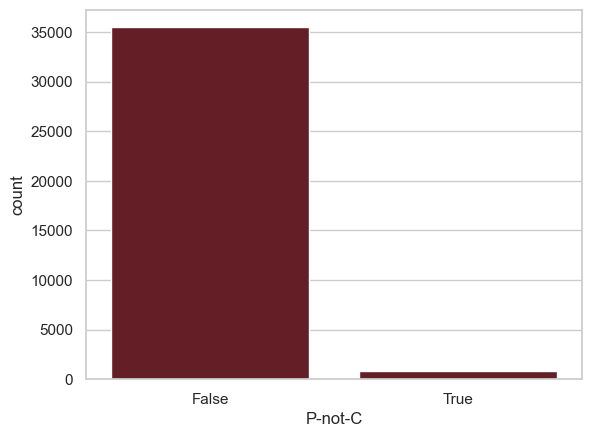

In [37]:
sns.countplot(x="P-not-C", data=data)

[Text(0, 0, '24396'), Text(0, 0, '11889')]

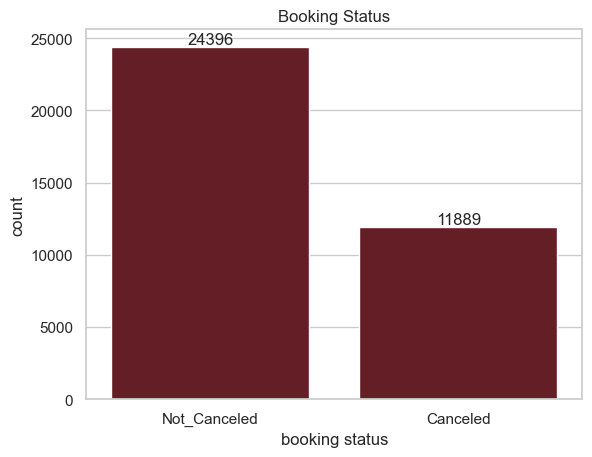

In [38]:
ax = sns.countplot(x="booking status", data=data)
ax.set_title("Booking Status")
values = data['booking status'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values)

Booking Status - From The data we have, We can see that in total, Most customers didnt cancel their booking. 

## Lets see booking patterns

[Text(0, 0, '28138'),
 Text(0, 0, '6059'),
 Text(0, 0, '966'),
 Text(0, 0, '692'),
 Text(0, 0, '265'),
 Text(0, 0, '158'),
 Text(0, 0, '7')]

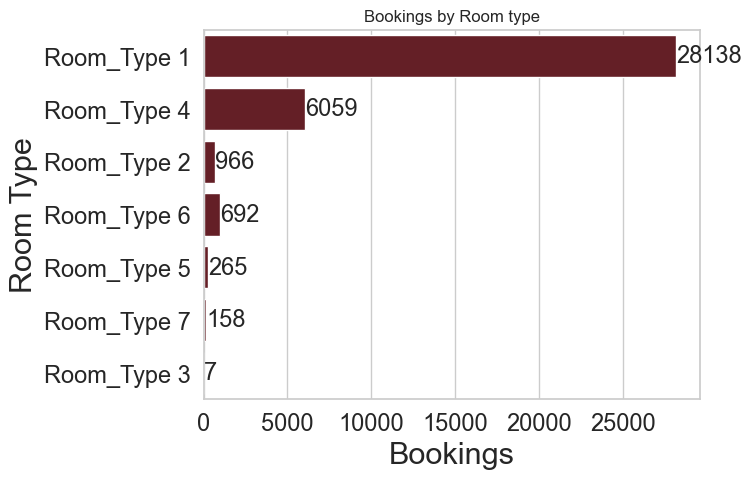

In [39]:
# fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(25,13))

ax = sns.countplot(y="room type", data=data)
ax.set_title("Bookings by Room type")
plt.ylabel("Room Type", fontsize=22)
plt.xlabel('Bookings', fontsize=22)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
values1 = data['room type'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values1, fontsize='17')

[Text(0, 0, '23221'),
 Text(0, 0, '10531'),
 Text(0, 0, '2017'),
 Text(0, 0, '391'),
 Text(0, 0, '125')]

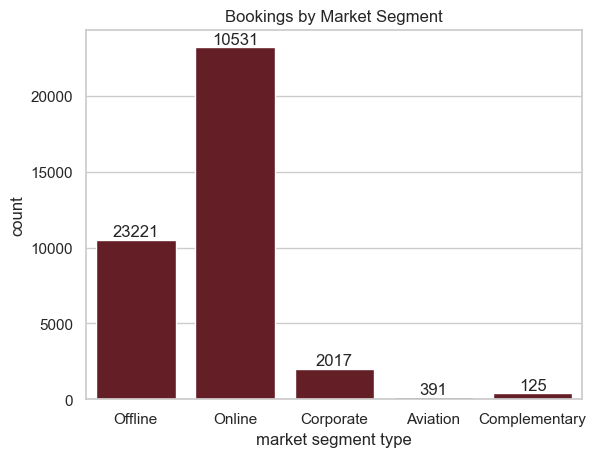

In [40]:
ax = sns.countplot(x="market segment type", data=data)
ax.set_title("Bookings by Market Segment")
values2 = data['market segment type'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values2)

Room Type - Room Type 1 had the most bookings with 28138 booked followed by Room type 4 with 6059. The least room type booked is Room type 3 with just 7 bookings. 

Market segment - The highest bookings are made online with 10531. Offline customers had 23221 bookings. Corporate, complementary and aviation bookings were less than 2000 with Aviation type customers having just 391 bookings. 

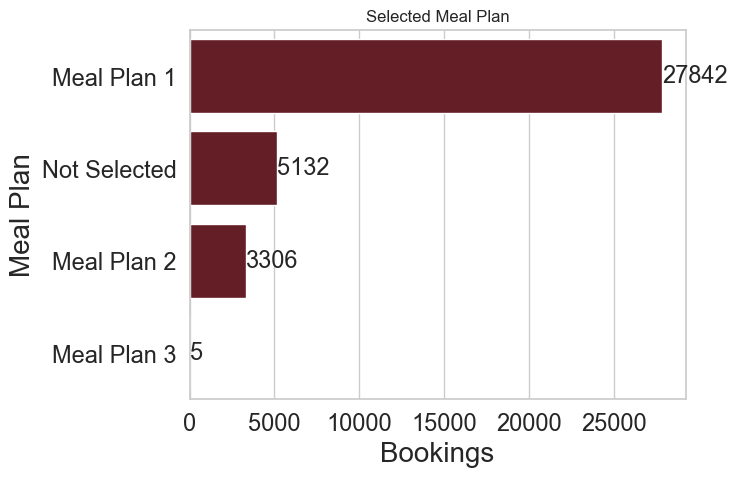

In [41]:
ax = sns.countplot(y="type of meal", data=data)
ax.set_title("Selected Meal Plan")
plt.ylabel("Meal Plan", fontsize=20)
plt.xlabel('Bookings', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
values = data['type of meal'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values, fontsize='17')

We can see that while 5132 bookings were made without a meal selection, Most bookings were made with meal selections and most customers preffered meal type 1. about 3306 bookings were made with Meal plan 2 and just 5 bookings were made with Meal plan 3. 5132 bookings were made without any meal plan selected.

[Text(0, 0, '35355'), Text(0, 0, '930')]

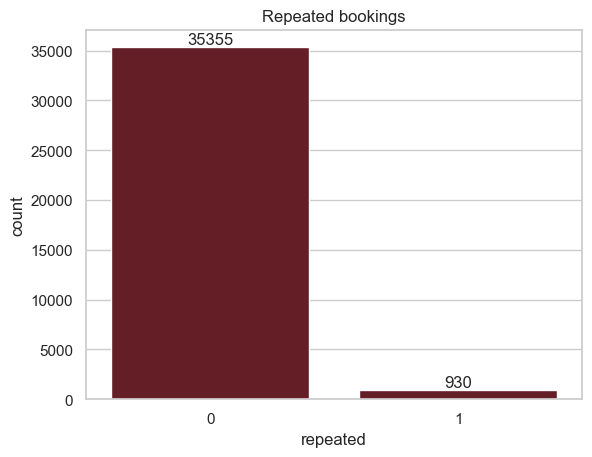

In [42]:
ax = sns.countplot(x="repeated", data=data)
ax.set_title("Repeated bookings")
values = data['repeated'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values)

Just 930 bookings were repeated bookings as most bookings were new bookings (35355). 

[Text(0, 0, '35161'), Text(0, 0, '1124')]

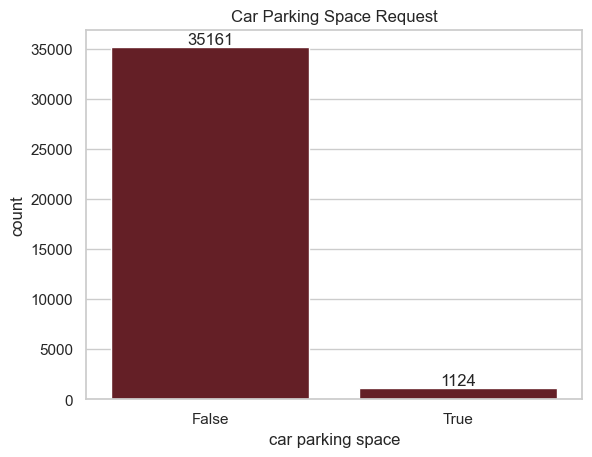

In [43]:
ax = sns.countplot(x="car parking space", data=data)
ax.set_title("Car Parking Space Request")
values = data['car parking space'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values)

Most bookings were made without a car parking space request. Just 1124 bookings were made with a car parking space request.

[Text(0, 0, '19780'),
 Text(0, 0, '11379'),
 Text(0, 0, '4364'),
 Text(0, 0, '676'),
 Text(0, 0, '78'),
 Text(0, 0, '8')]

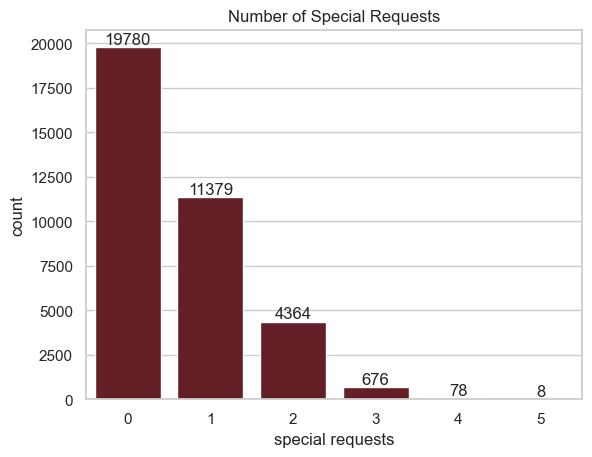

In [44]:
ax = sns.countplot(x="special requests", data=data)
ax.set_title("Number of Special Requests")
values = data['special requests'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values)

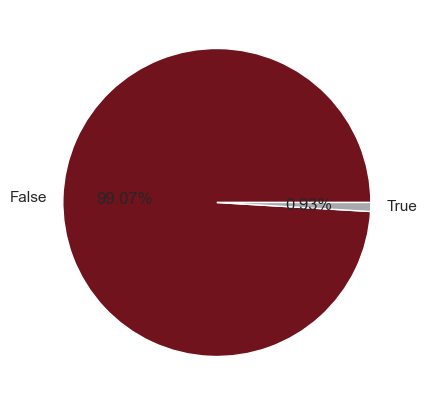

In [45]:
# Lets see who were customers and who were not 
from collections import Counter #counter
fig, ax = plt.subplots(figsize=(5,5))
count = Counter(data["P-C"])
ax.pie(count.values(), labels=count.keys(), colors = ["#70131D", "#A7A9AC"], autopct=lambda p:f'{p:.2f}%')
plt.show()

Most of the customers that made bookings didnt have customer profiles. Just 1 percent were customers. 

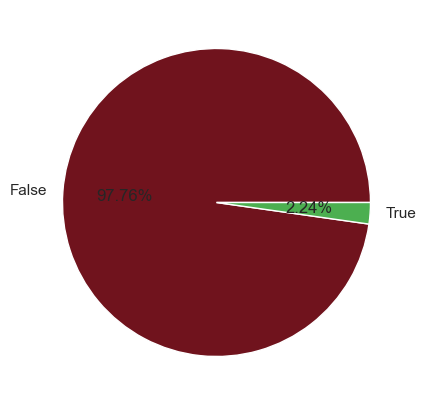

In [46]:
## P-not-C -  not not customers
fig, ax = plt.subplots(figsize=(5,5))
count = Counter(data["P-not-C"])
ax.pie(count.values(), labels=count.keys(), autopct=lambda p:f'{p:.2f}%')
plt.show()

## BiVariate Analysis 

/var/folders/sh/gcscsq2909v05dypcv70_w880000gn/T/ipykernel_5426/3154426283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='booking status', y='lead time', data=data, palette = ["#70131D", "#A7A9AC"])


<Axes: xlabel='booking status', ylabel='lead time'>

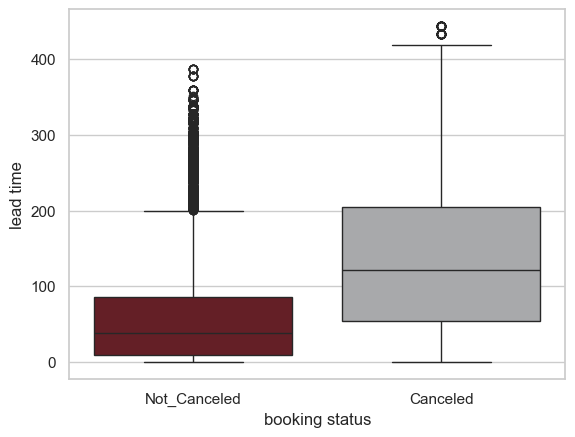

In [47]:
# lets see lead time by cancellations
sns.boxplot(x='booking status', y='lead time', data=data, palette = ["#70131D", "#A7A9AC"])

From the chart above. We can see that customers who booked wayy ahead with about 100 days of lead time usually ended up cancelling. Most customers who booked with shorter lead time usually didnt cancel. 

<Axes: xlabel='booking status', ylabel='average price'>

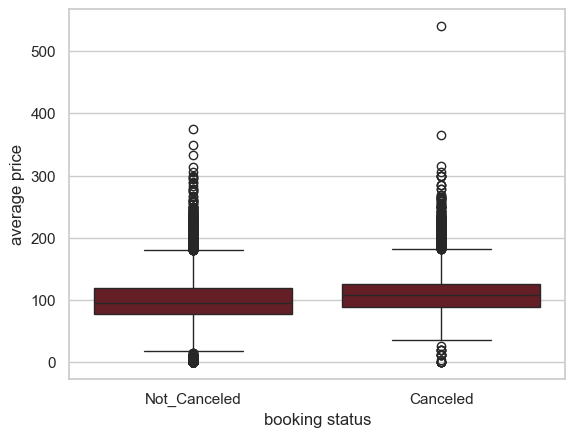

In [48]:
sns.boxplot(x='booking status', y='average price', data=data)

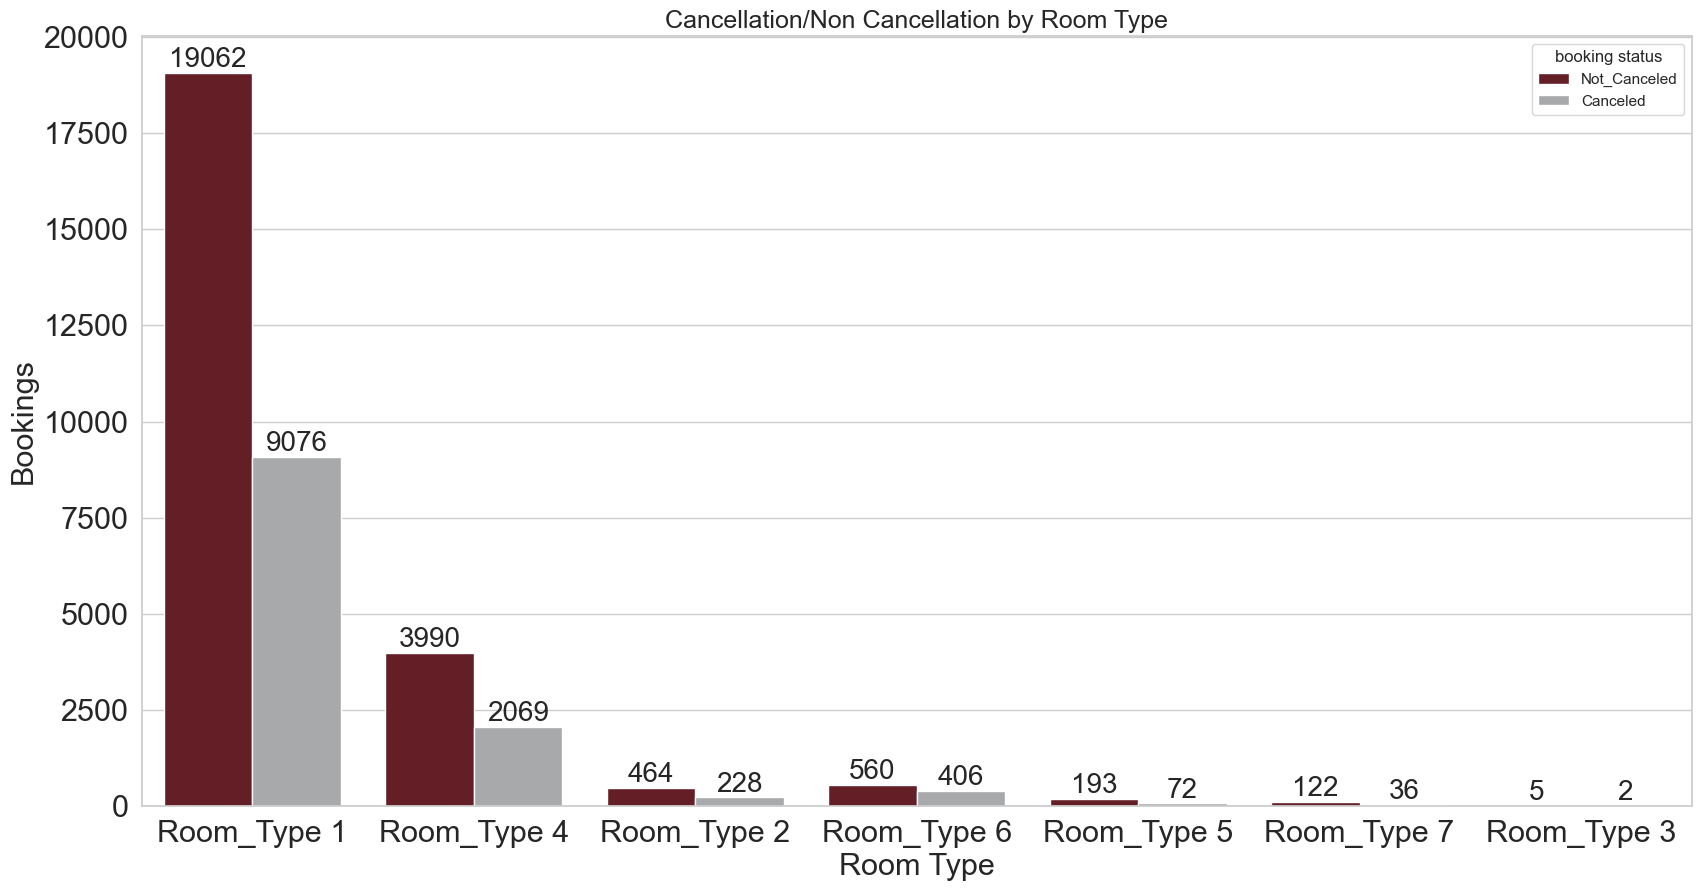

In [49]:
# Lets see various preferences with cancellations to see who cancels 
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='room type', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
ax.set_title("Cancellation/Non Cancellation by Room Type", fontsize='18')
plt.xlabel("Room Type", fontsize=22)
plt.ylabel('Bookings', fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
values = data['room type'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values, fontsize='20')

plt.show()

We can see that room type 1 had the most cancelled byt also not cancelled. 

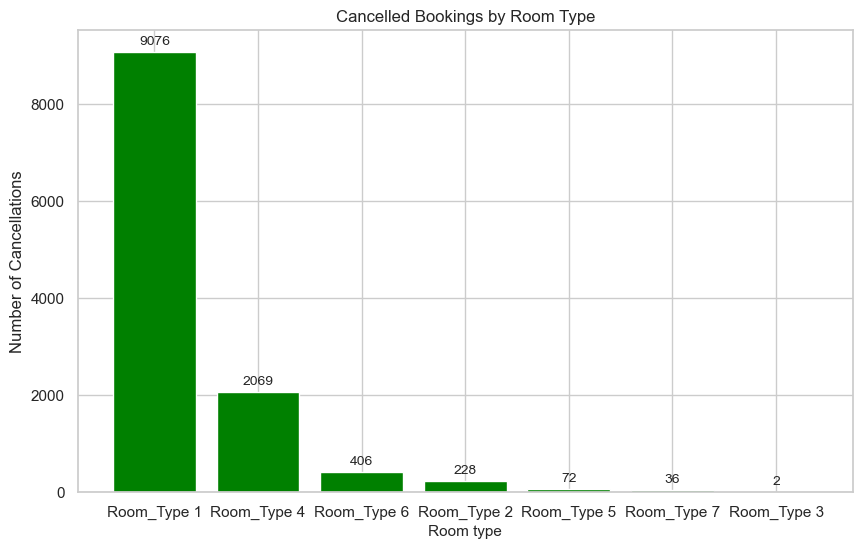

In [50]:
# Filter cancelled only, then groupby room type and count
cancelled = data[data['booking status'] == 'Canceled']
cancelled_counts = cancelled.groupby('room type')['booking status'].count().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(cancelled_counts.index, cancelled_counts.values, color='green')

# Add bar labels
ax.bar_label(bars, fmt='%d', label_type='edge', fontsize=10, padding=3)
ax.set_title("Cancelled Bookings by Room Type")
ax.set_xlabel("Room type", fontsize=11)
ax.set_ylabel("Number of Cancellations")

plt.show()


we can see that bookings with type room 1 had the highest cancellation rate. Although we arent clear because the non cancellations are also proportional to this. 
Lets look at other markers

In [51]:
# Filter cancelled only, then groupby market segment and count
cancelled = data[data['booking status'] == 'Canceled']
cancelled_counts = cancelled.groupby('market segment type')['booking status'].count().sort_values(ascending=False)

cancelled

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,year,month,day_of_week
2,INN00003,2,1,1,3,Meal Plan 1,False,Room_Type 1,1,Online,0,False,False,50.0,0,2018-02-28,Canceled,2018.0,Feb,Wed
3,INN00004,1,0,0,2,Meal Plan 1,False,Room_Type 1,211,Online,0,False,False,100.0,1,2017-05-20,Canceled,2017.0,May,Sat
4,INN00005,1,0,1,2,Not Selected,False,Room_Type 1,48,Online,0,False,False,77.0,0,2018-11-04,Canceled,2018.0,Nov,Sun
5,INN00006,1,0,0,2,Meal Plan 2,False,Room_Type 1,346,Offline,0,False,False,100.0,1,2016-09-13,Canceled,2016.0,Sep,Tue
12,INN00013,2,0,2,1,Not Selected,False,Room_Type 1,30,Online,0,False,False,88.0,0,2018-11-26,Canceled,2018.0,Nov,Mon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36273,INN36274,2,0,0,3,Not Selected,False,Room_Type 1,63,Online,0,False,False,94.5,0,2018-04-21,Canceled,2018.0,Apr,Sat
36277,INN36278,1,0,2,1,Meal Plan 1,False,Room_Type 1,1,Online,0,False,False,60.0,0,2018-02-28,Canceled,2018.0,Feb,Wed
36278,INN36279,2,0,0,2,Meal Plan 1,False,Room_Type 1,211,Online,0,False,False,100.0,0,2018-05-20,Canceled,2018.0,May,Sun
36279,INN36281,2,0,1,1,Not Selected,False,Room_Type 1,48,Online,0,False,False,94.5,0,2018-11-04,Canceled,2018.0,Nov,Sun


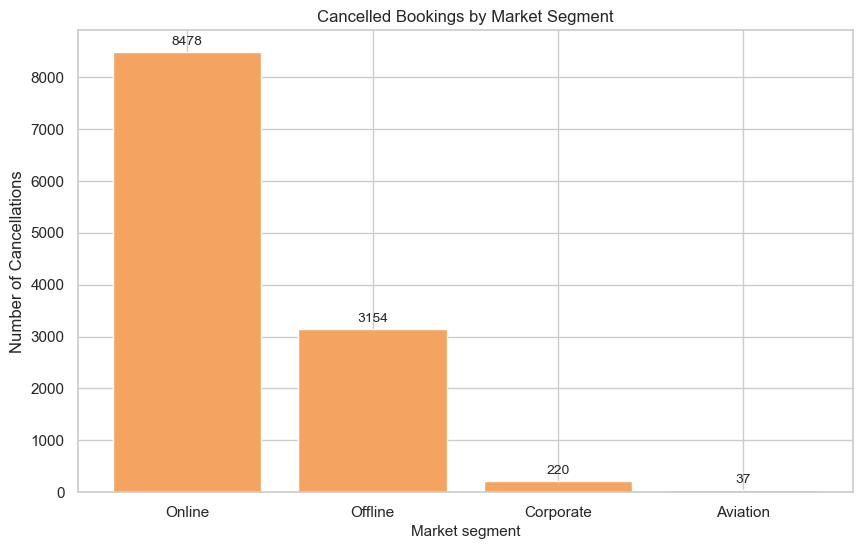

In [52]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(cancelled_counts.index, cancelled_counts.values, color='sandybrown')

# Add bar labels
ax.bar_label(bars, fmt='%d', label_type='edge', fontsize=10, padding=3)
ax.set_title("Cancelled Bookings by Market Segment")
ax.set_xlabel("Market segment", fontsize=11)
ax.set_ylabel("Number of Cancellations")

plt.show()

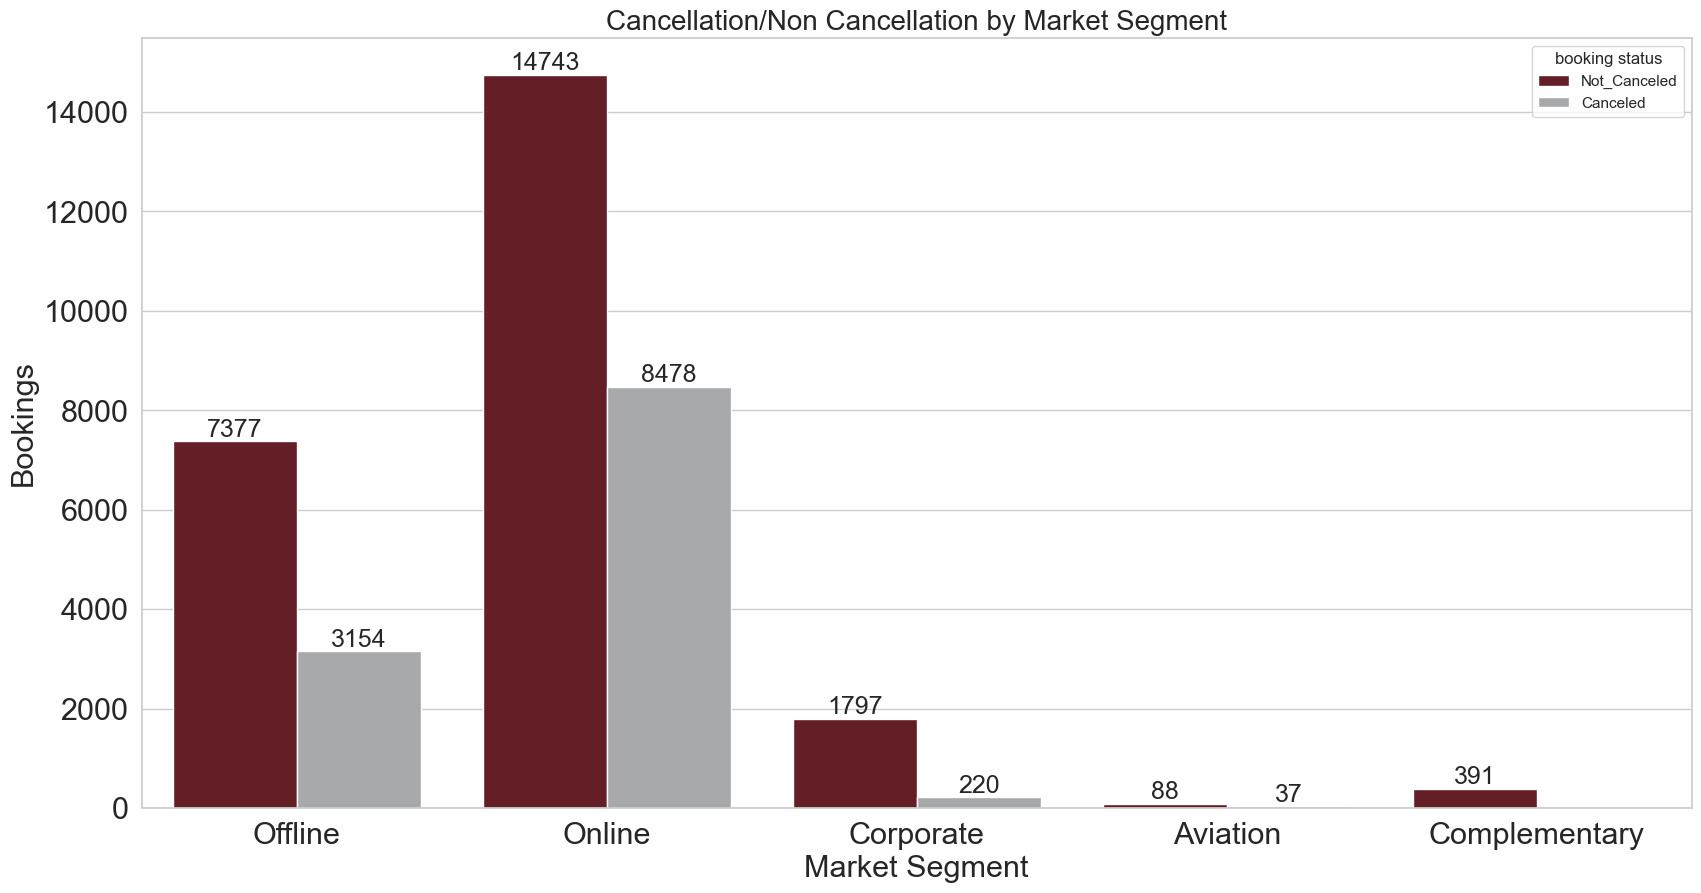

In [53]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='market segment type', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
ax.set_title("Cancellation/Non Cancellation by Market Segment", fontsize='20')
plt.xlabel("Market Segment", fontsize=22)
plt.ylabel('Bookings', fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
values = data['market segment type'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values, fontsize='18')

plt.show()

Online bookings recorded the highest number of cancellations (8,478); however, this is proportional to their overall booking volume (14,743 non-cancellations). In contrast, complementary customers had no cancellations but was the channel with the lowest bookings. The higher cancellations are driven by scale rather than an unusually high cancellation rate.

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36285 non-null  object        
 1   number of adults          36285 non-null  int64         
 2   number of children        36285 non-null  int64         
 3   number of weekend nights  36285 non-null  int64         
 4   number of week nights     36285 non-null  int64         
 5   type of meal              36285 non-null  object        
 6   car parking space         36285 non-null  bool          
 7   room type                 36285 non-null  object        
 8   lead time                 36285 non-null  int64         
 9   market segment type       36285 non-null  object        
 10  repeated                  36285 non-null  int64         
 11  P-C                       36285 non-null  bool          
 12  P-not-C           

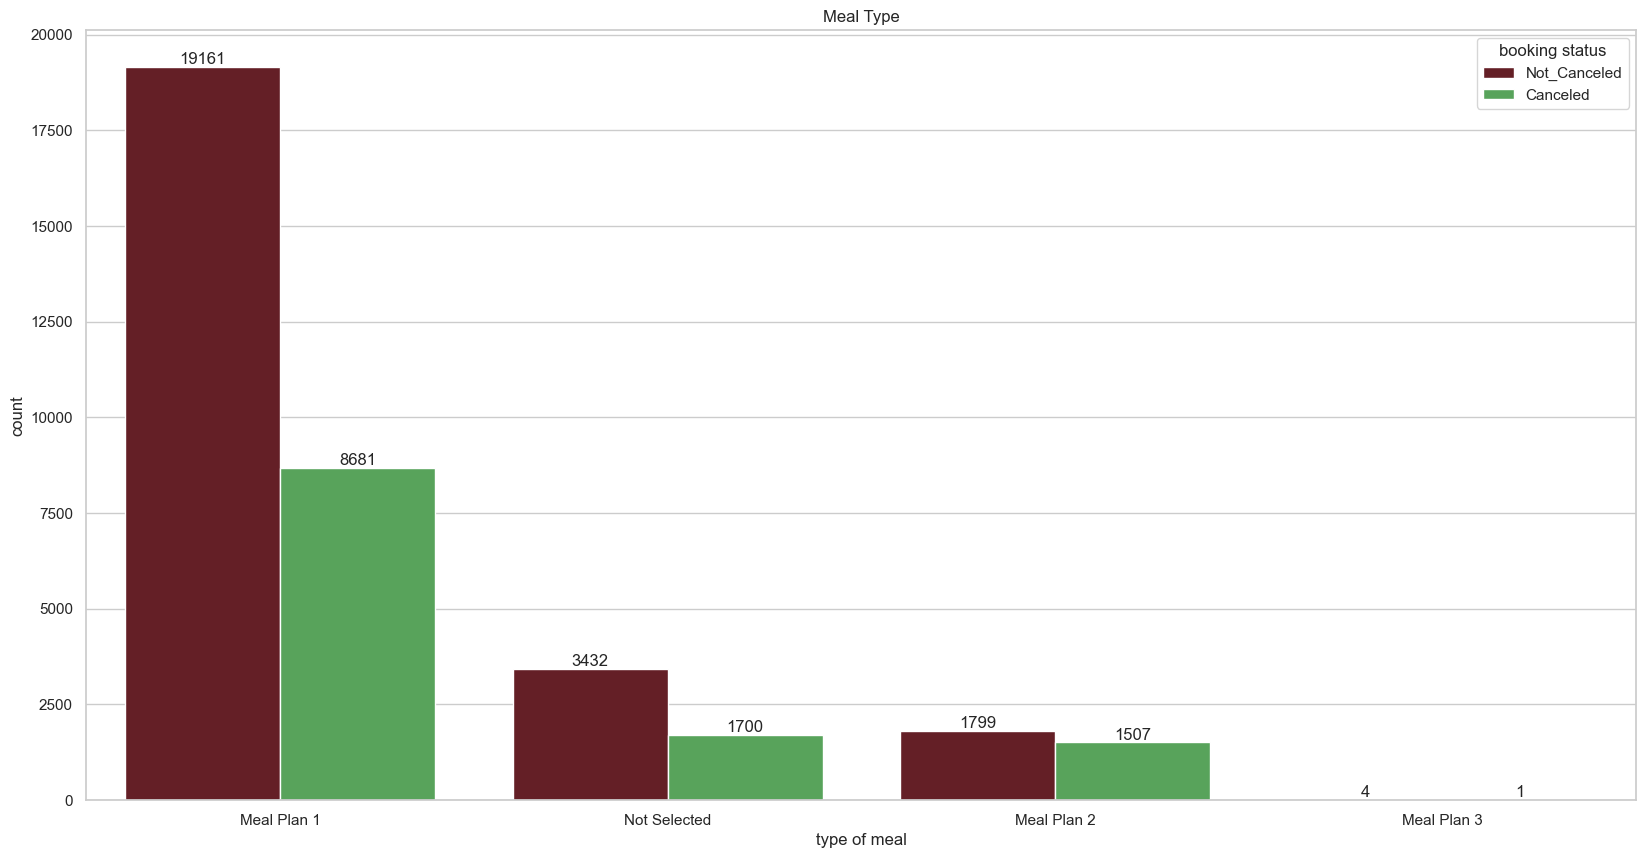

In [55]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='type of meal', hue='booking status', data=data)
ax.set_title("Meal Type")
values = data['type of meal'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values)

plt.show()

Bookings where Meal type 1 was chosen recorded the highest number of cancellations (8,681), this is proportional to their overall booking volume (19,161 non-cancellations. Meal plan 2 bookings, 1700 cancellations with 3432 non cancellations. 5132 bookings did not select any meal type and of those, 3432 didnt cancel while 1700 bookings were cancelled. The higher cancellations are driven by scale rather than an unusually high cancellation rate. This is same for other meal type categories. 

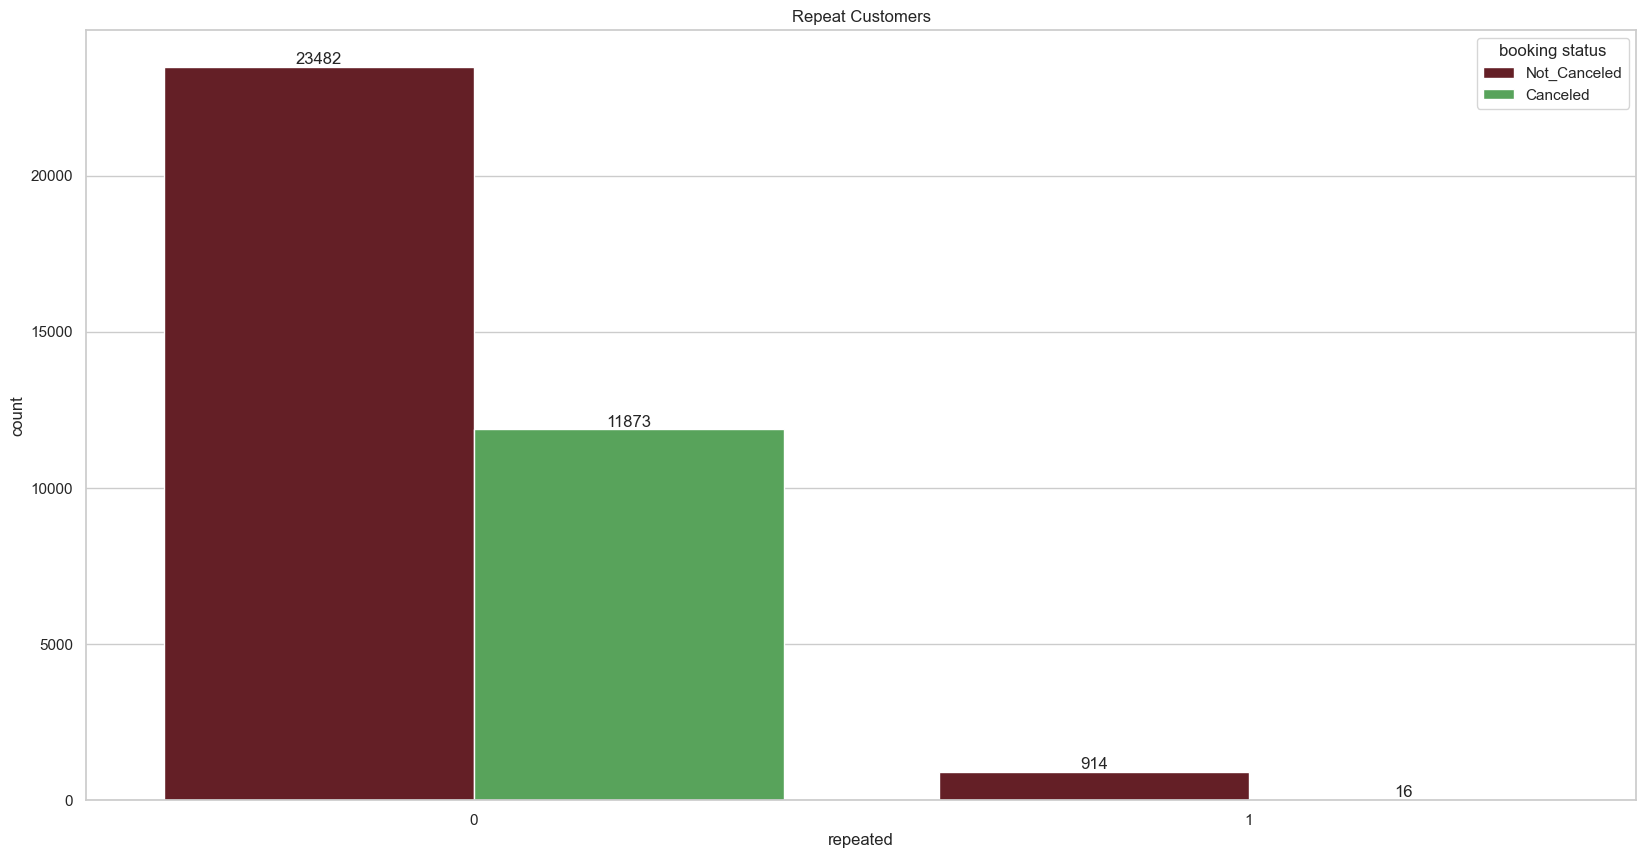

In [56]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='repeated', hue='booking status', data=data)
ax.set_title("Repeat Customers")
values = data['repeated'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values)

plt.show()

Most bookings were new bookings with 11,873 cancellations compared to 23482 non cancellations. Repeat bookings accounted for a smaller share of bookings 930 in total with only 16 cancellations. Could suggest that returning customers are looking for new or better services which would mean they didnt repeat their initial bookings. we would be able to know in further analyses. 

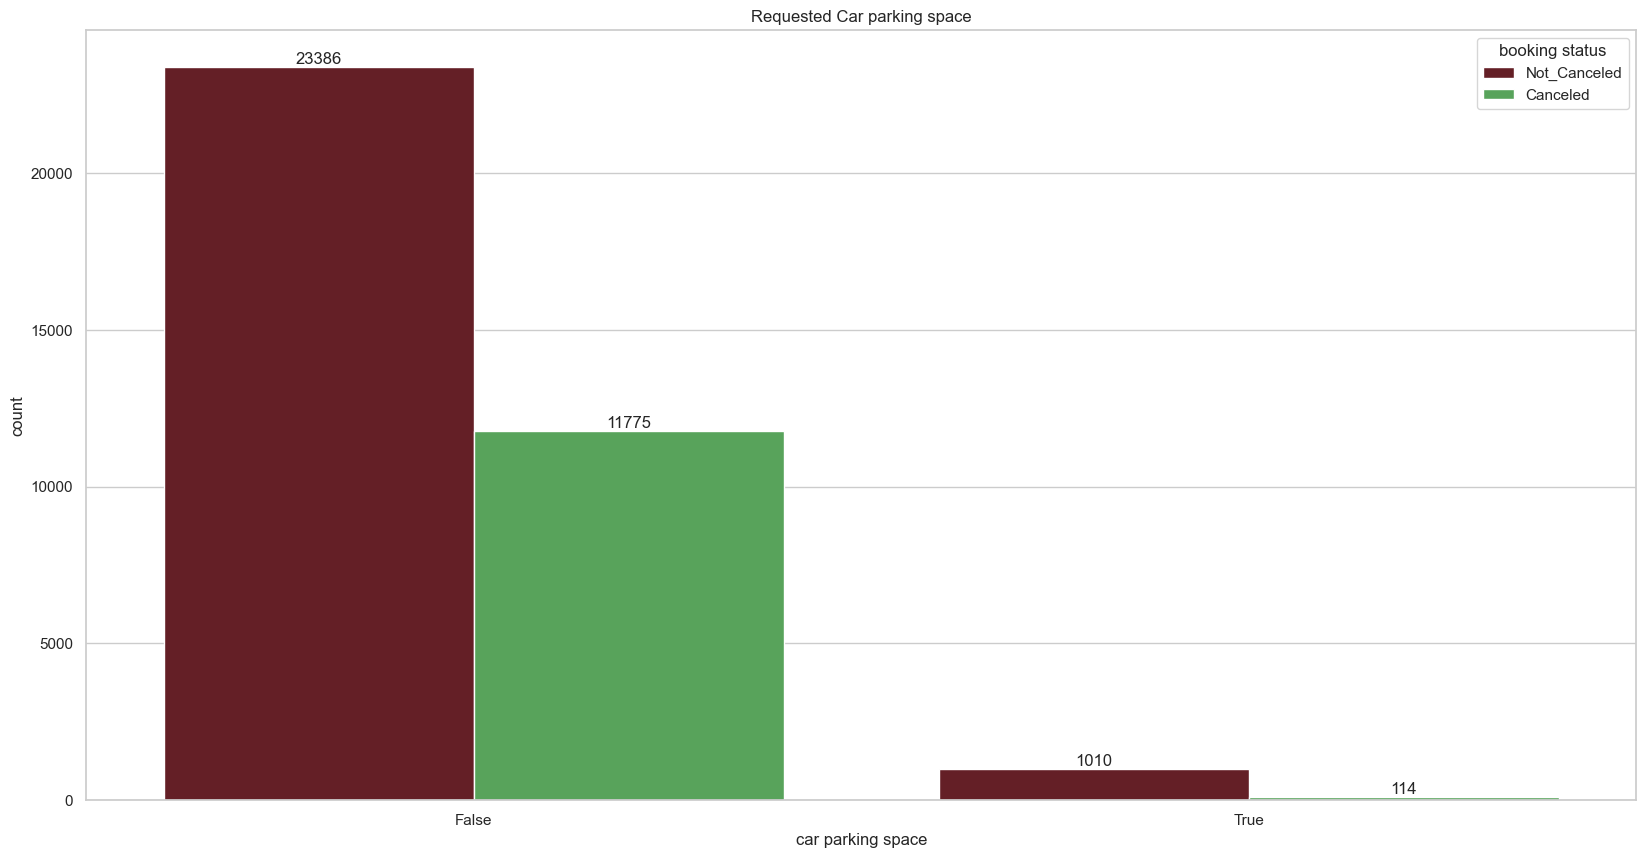

In [57]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='car parking space', hue='booking status', data=data)
ax.set_title("Requested Car parking space")
values = data['car parking space'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values)

plt.show()

The majority of bookings did not include a car parking space, with 11,775 cancellations compared to 23,386 non-cancellations. In contrast, bookings that included parking represented a much smaller share (1,124 in total), with only 114 cancellations and 1,010 completed bookings. This suggests that bookings with parking are less likely to be cancelled, indicating a higher level of commitment among these customers

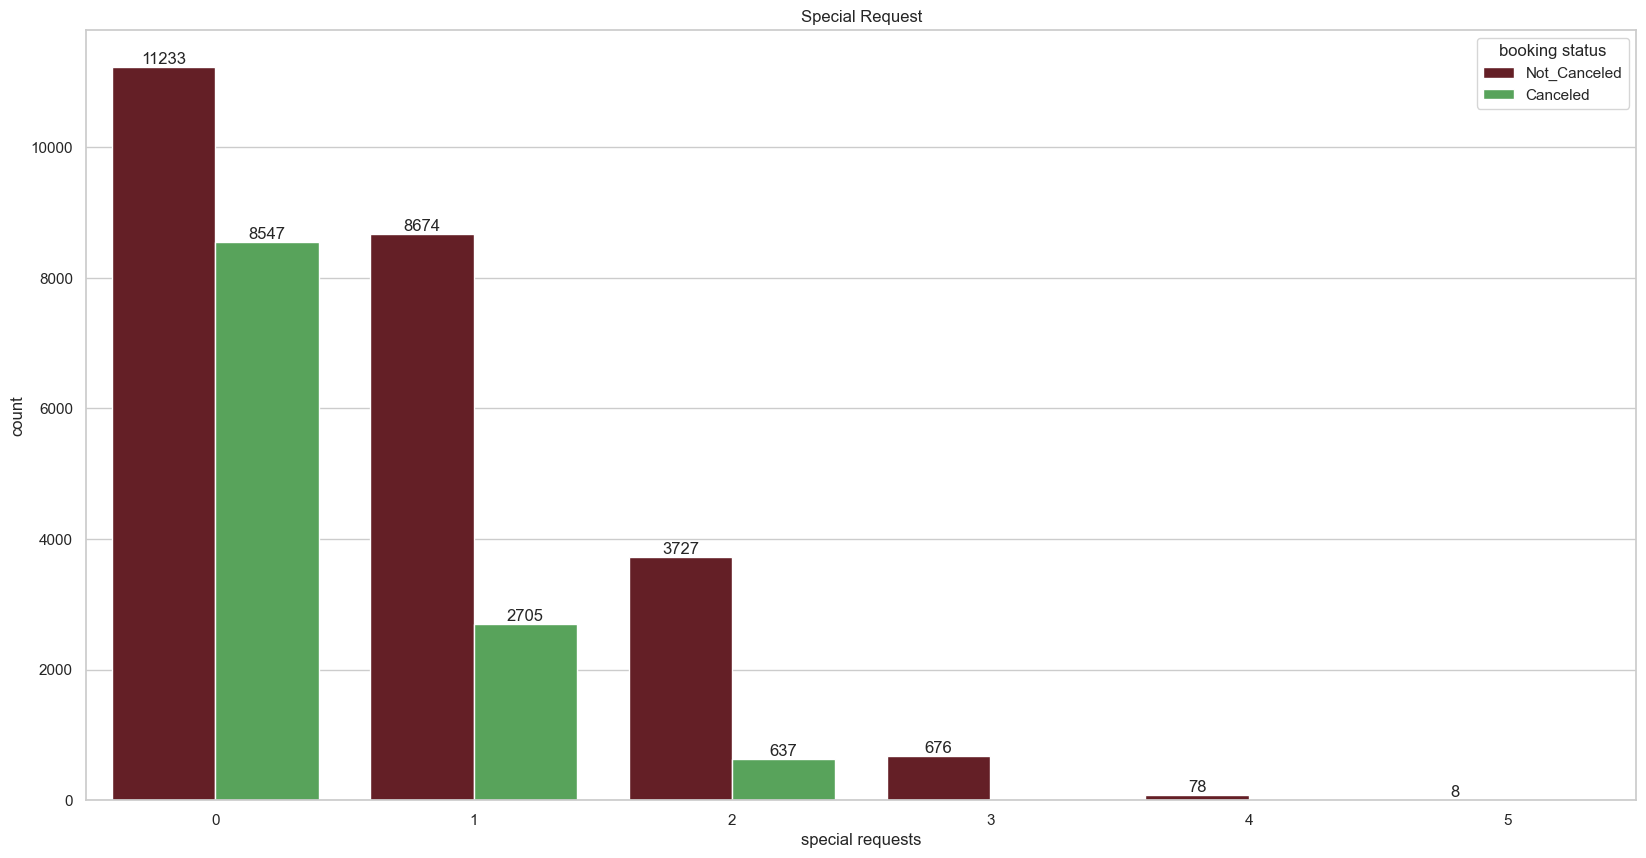

In [58]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(x='special requests', hue='booking status', data=data, )
ax.set_title("Special Request")
values = data['special requests'].value_counts(ascending=False).values
for container in ax.containers:
    ax.bar_label(container, label=values)

plt.show()

Text(0.5, 1.0, 'Number of week Nights by market segment')

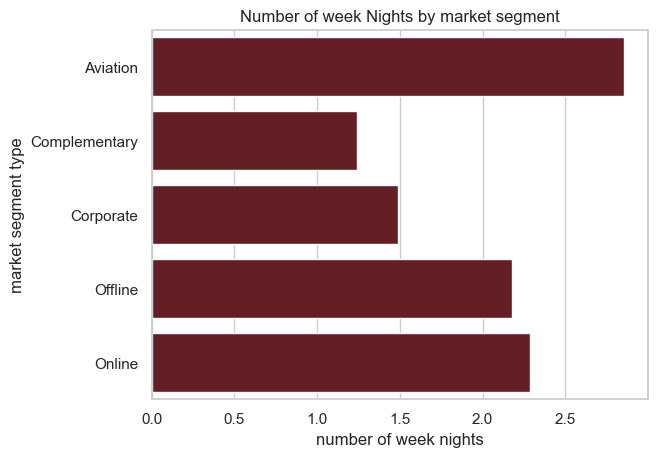

In [59]:
# No of week nights  by booking platform 
sp_prof = data.groupby("market segment type")["number of week nights"].mean().reset_index()
axa = sns.barplot(x = 'number of week nights', data =sp_prof, y= 'market segment type')
axa.set_title("Number of week Nights by market segment")

Text(0.5, 1.0, 'Number of weekend Nights by market segment')

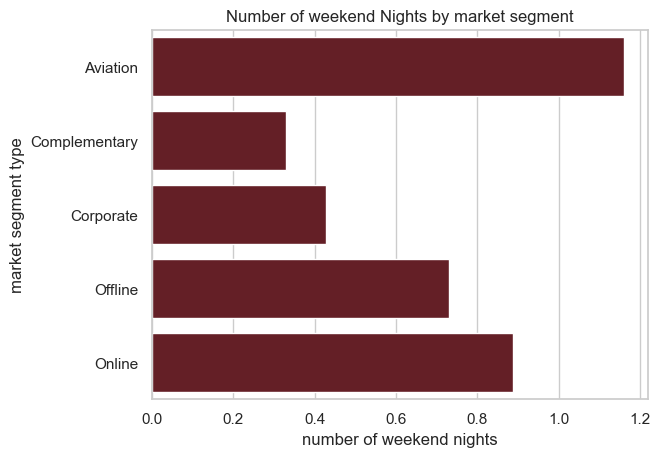

In [60]:
# No of weekend nights  by booking platform 
sp_prof = data.groupby("market segment type")["number of weekend nights"].mean().reset_index()
axa = sns.barplot(x = 'number of weekend nights', data =sp_prof, y= 'market segment type')
axa.set_title("Number of weekend Nights by market segment")

Text(0.5, 1.0, 'Number of weekend Nights by room type')

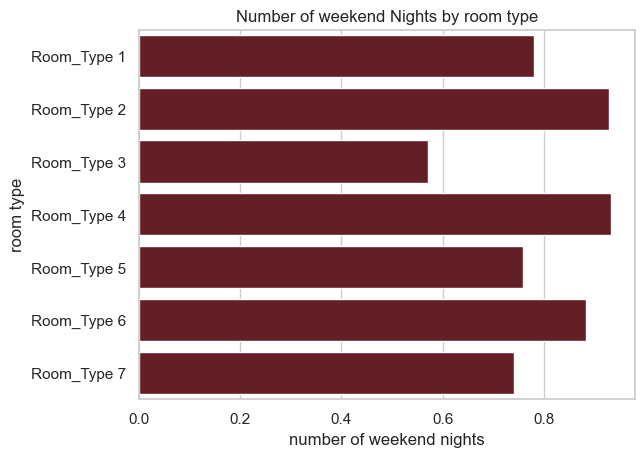

In [61]:
sp_prof = data.groupby("room type")["number of weekend nights"].mean().reset_index()
axa = sns.barplot(x = 'number of weekend nights', data =sp_prof, y= 'room type')
axa.set_title("Number of weekend Nights by room type")

Text(0.5, 1.0, 'Number of week Nights by room type')

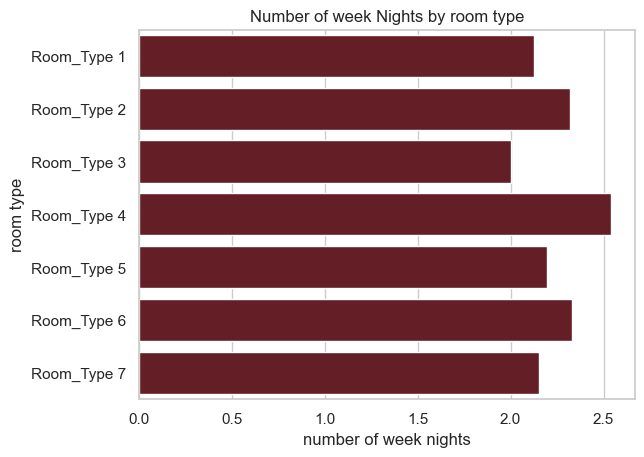

In [62]:
sp_prof = data.groupby("room type")["number of week nights"].mean().reset_index()
axa = sns.barplot(x = 'number of week nights', data =sp_prof, y= 'room type')
axa.set_title("Number of week Nights by room type")

Text(0.5, 1.0, 'Number of week Nights by booking status')

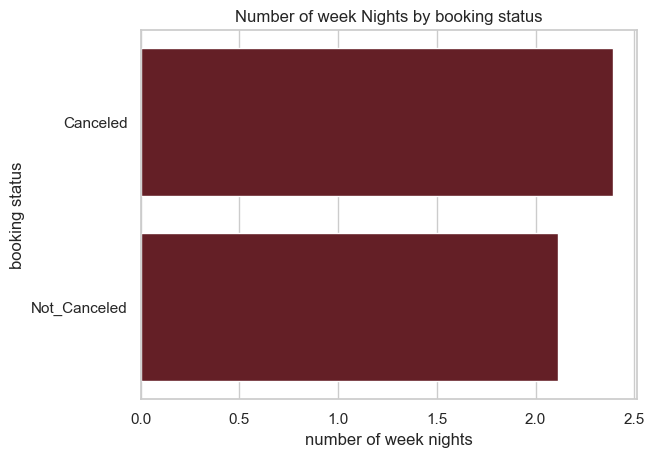

In [63]:
sp_prof = data.groupby("booking status")["number of week nights"].mean().reset_index()
axa = sns.barplot(x = 'number of week nights', data =sp_prof, y= 'booking status')
axa.set_title("Number of week Nights by booking status")

Text(0.5, 1.0, 'Number of weekend Nights by booking status')

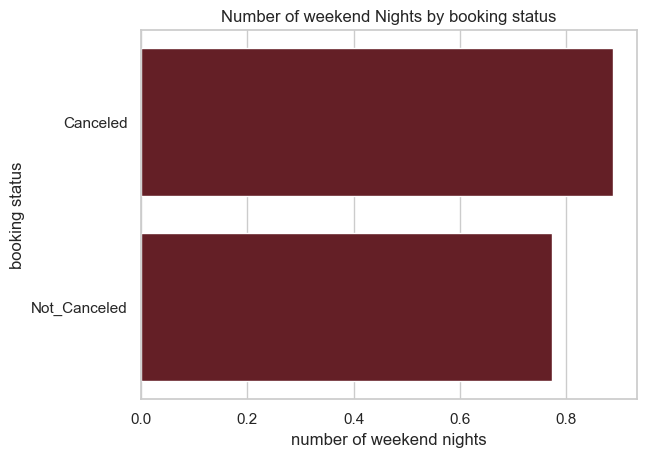

In [64]:
sp_prof = data.groupby("booking status")["number of weekend nights"].mean().reset_index()
axa = sns.barplot(x = 'number of weekend nights', data =sp_prof, y= 'booking status')
axa.set_title("Number of weekend Nights by booking status")

Text(0.5, 1.0, 'Average price by Room type')

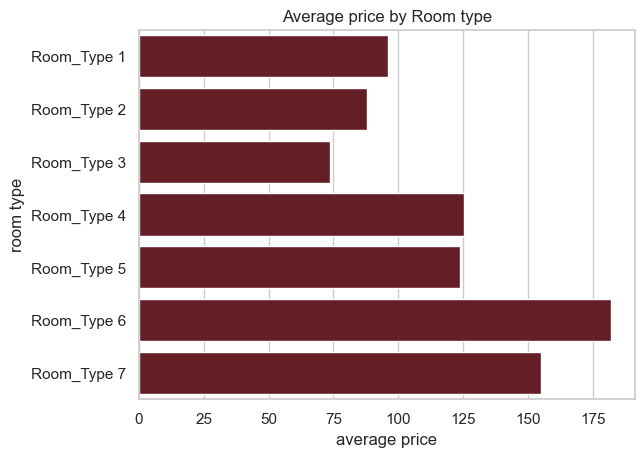

In [65]:
sp_prof = data.groupby("room type")["average price"].mean().reset_index()
axa = sns.barplot(x = 'average price', data =sp_prof, y= 'room type')
axa.set_title("Average price by Room type")

<Axes: xlabel='average price', ylabel='Count'>

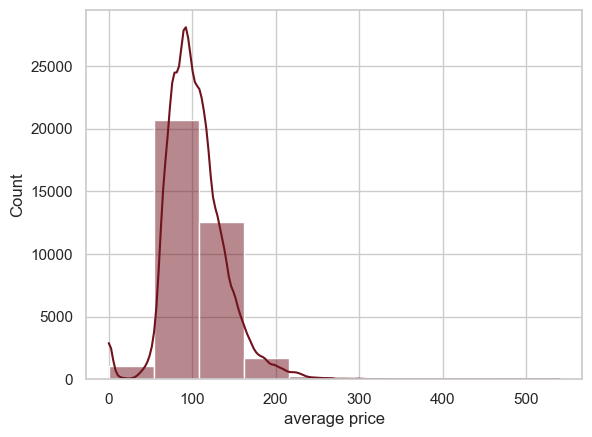

In [66]:
sns.histplot(data['average price'], bins = 10, kde = True )

In [67]:
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,lead time,repeated,average price,special requests,date of reservation
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36248
mean,1.844839,0.105360,0.810693,2.204602,85.239851,0.025630,103.421636,0.619733,2018-05-10 23:23:58.093136384
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015-02-10 00:00:00
25%,2.000000,0.000000,0.000000,1.000000,17.000000,0.000000,80.300000,0.000000,2018-02-11 00:00:00
50%,2.000000,0.000000,1.000000,2.000000,57.000000,0.000000,99.450000,0.000000,2018-06-03 12:00:00
75%,2.000000,0.000000,2.000000,3.000000,126.000000,0.000000,120.000000,1.000000,2018-09-13 00:00:00
max,4.000000,10.000000,7.000000,17.000000,443.000000,1.000000,540.000000,5.000000,2018-12-31 00:00:00
std,0.518813,0.402704,0.870590,1.410946,85.938796,0.158032,35.086469,0.786262,NaN


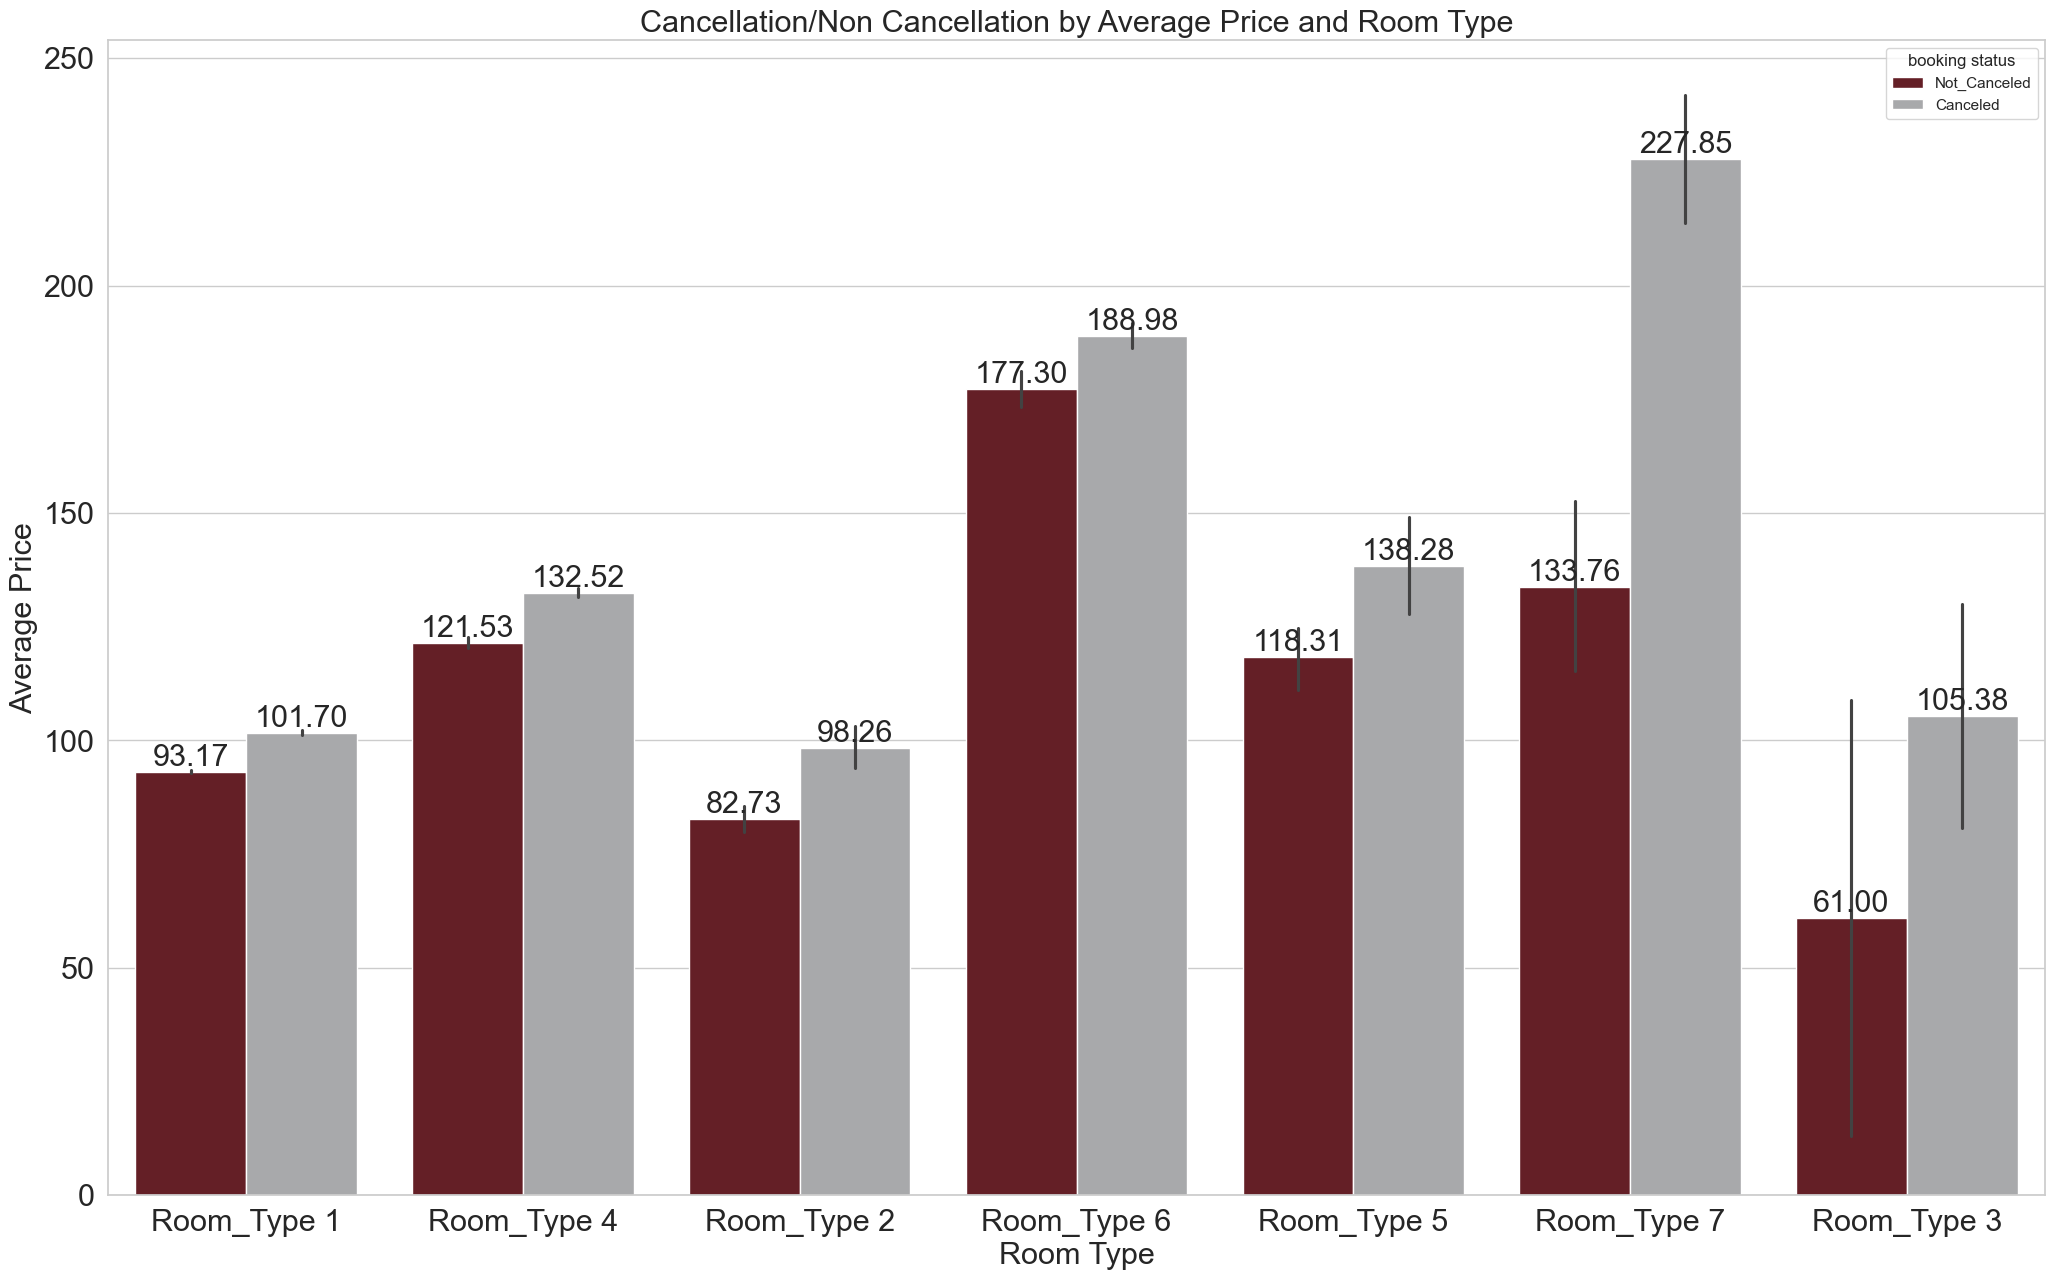

In [68]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='room type', y='average price', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
axs.set_title("Cancellation/Non Cancellation by Average Price and Room Type", fontsize='22')
plt.xlabel("Room Type", fontsize=22)
plt.ylabel('Average Price', fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.2f', fontsize= 22)
plt.show()

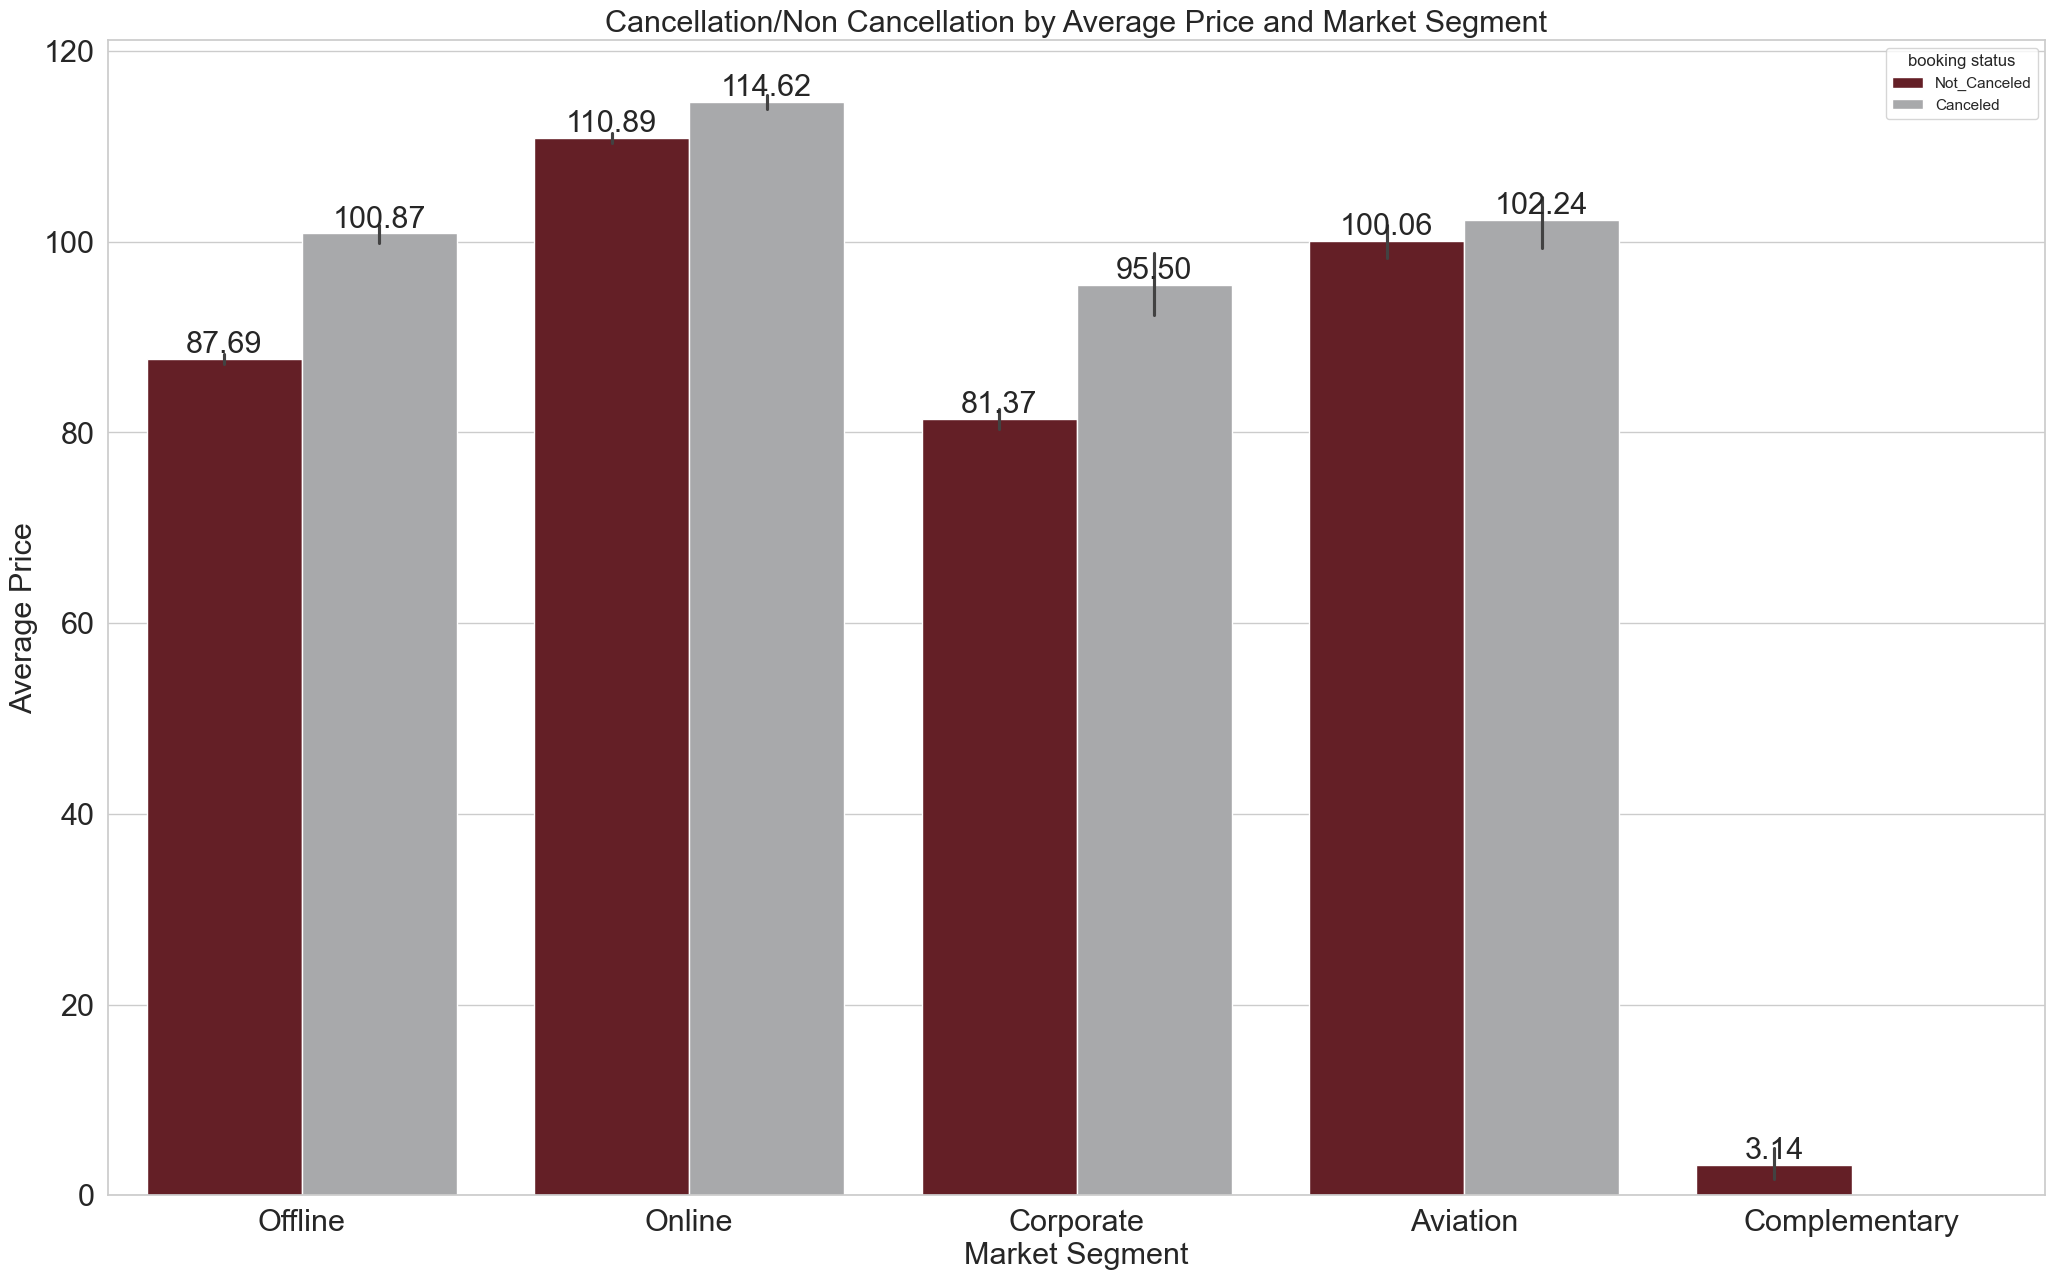

In [69]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='market segment type', y='average price', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
axs.set_title("Cancellation/Non Cancellation by Average Price and Market Segment", fontsize='22')
plt.xlabel("Market Segment", fontsize=22)
plt.ylabel('Average Price', fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.2f', fontsize= 22)
plt.show()

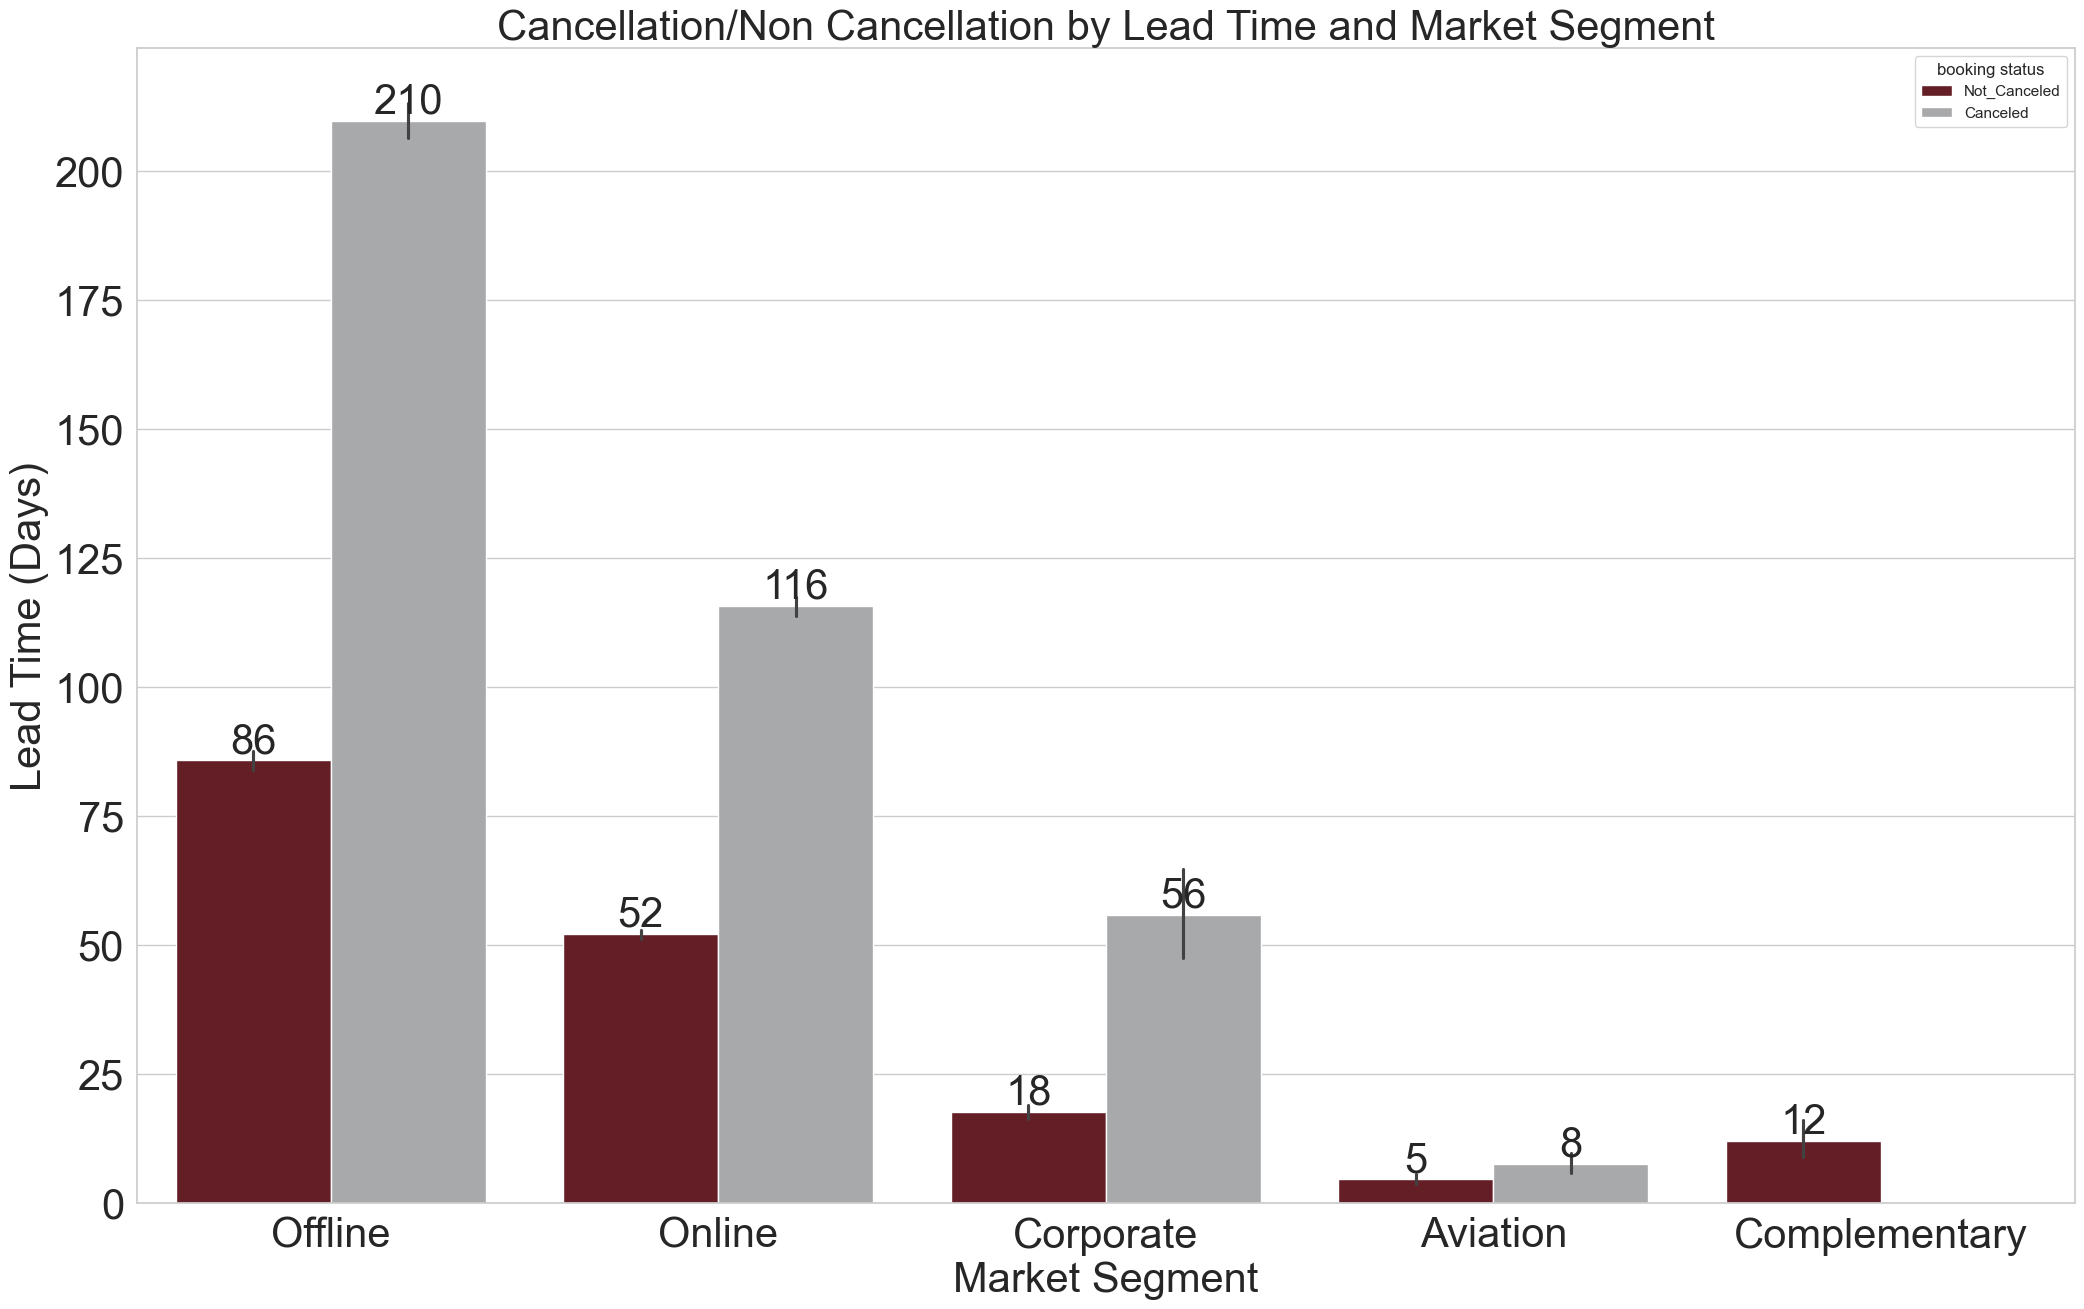

In [70]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='market segment type', y='lead time', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
axs.set_title("Cancellation/Non Cancellation by Lead Time and Market Segment", fontsize='30')
plt.xlabel("Market Segment", fontsize=30)
plt.ylabel('Lead Time (Days)', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.0f', fontsize= 30)
plt.show()

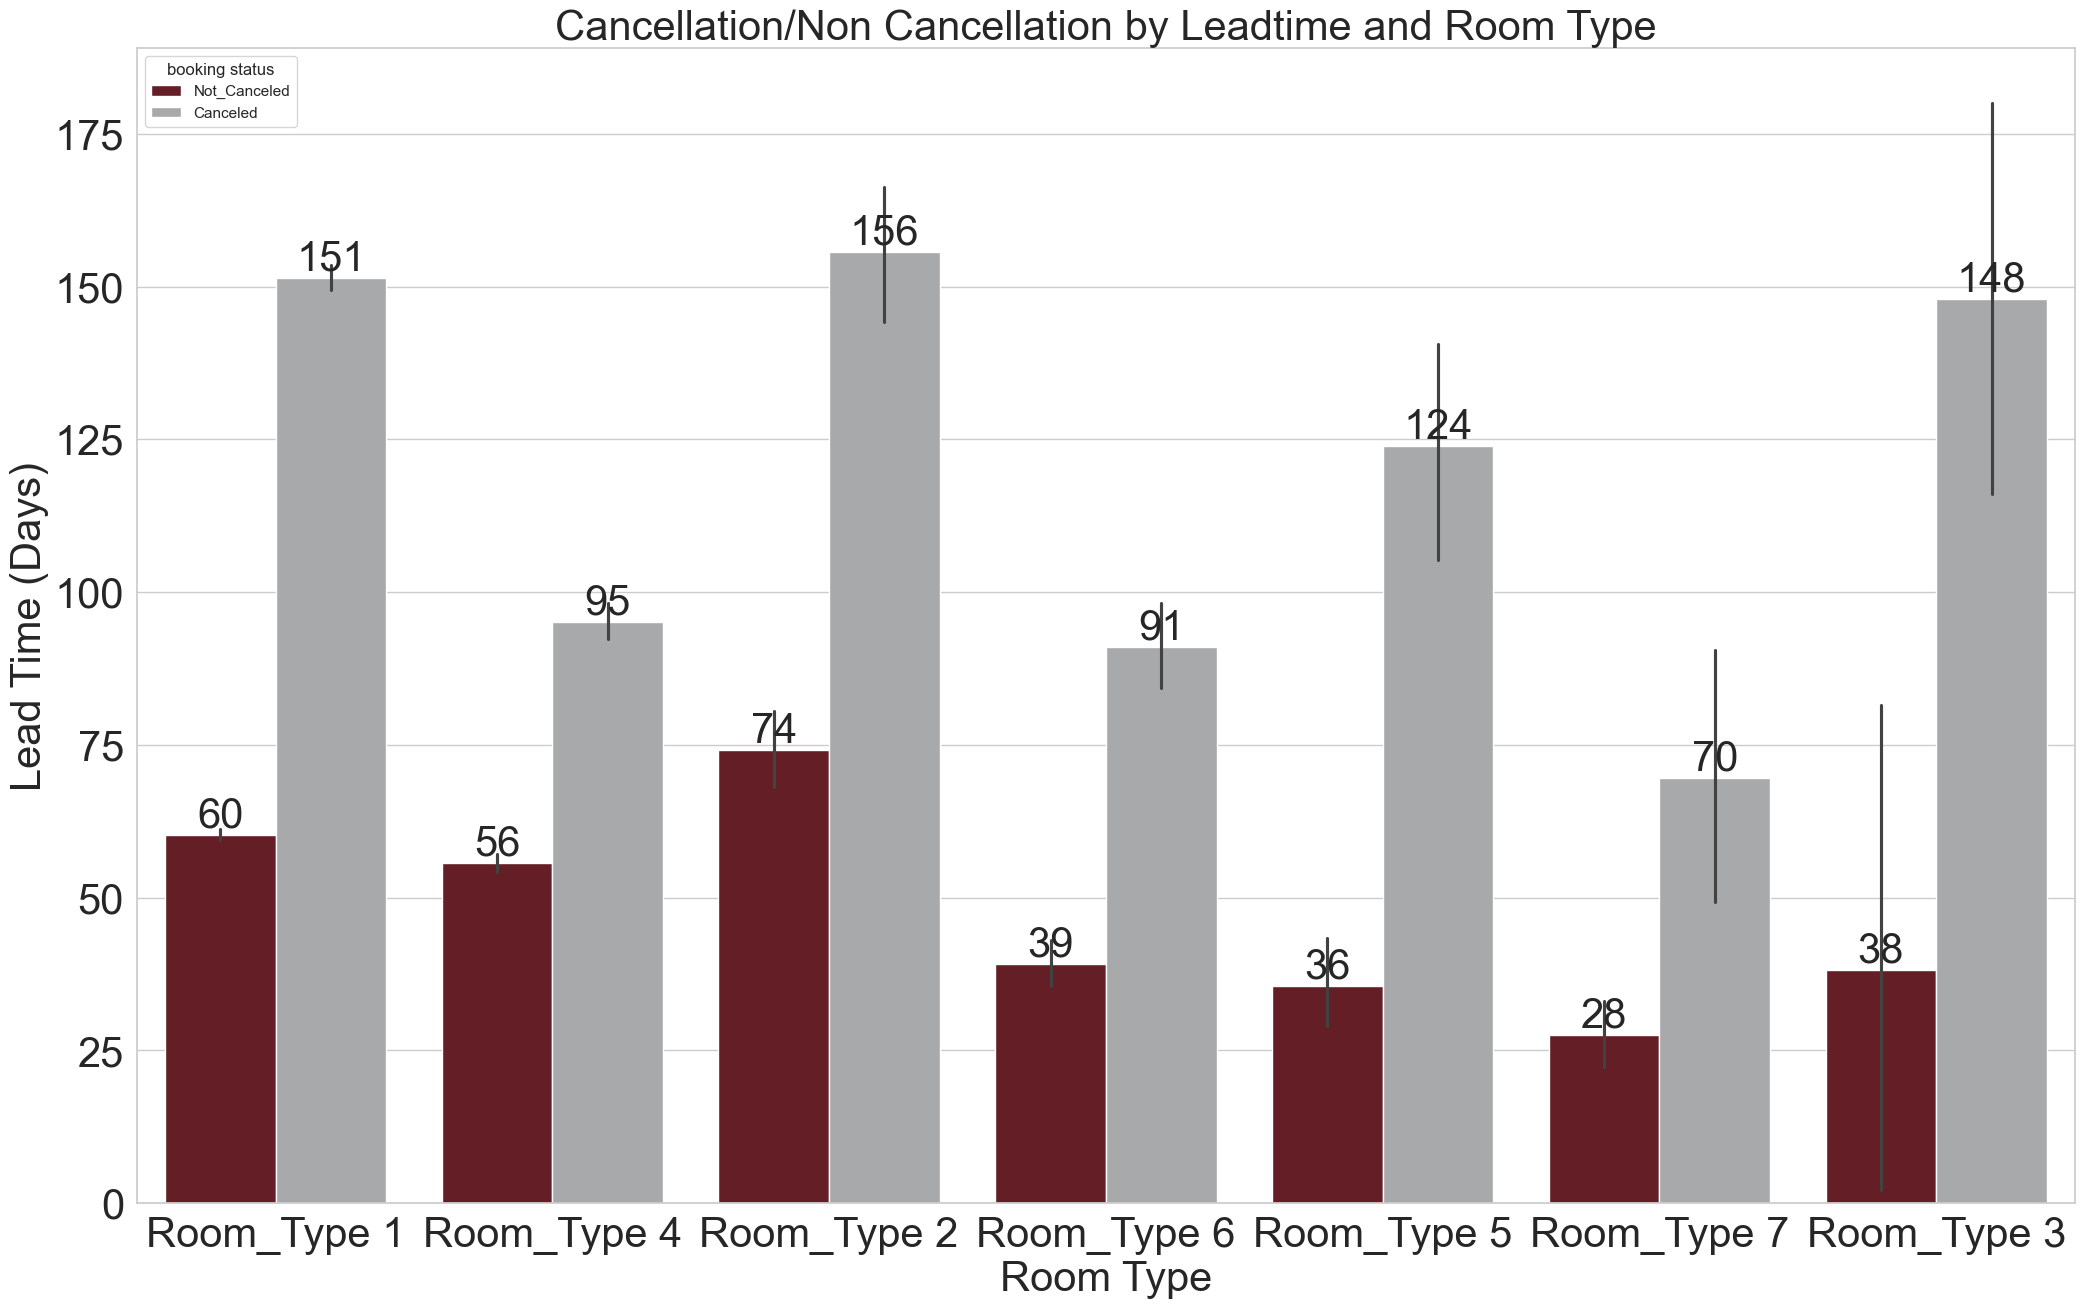

In [71]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='room type', y='lead time', hue='booking status', data=data, palette = ["#70131D", "#A7A9AC"])
axs.set_title("Cancellation/Non Cancellation by Leadtime and Room Type", fontsize='30')
plt.xlabel("Room Type", fontsize=30)
plt.ylabel('Lead Time (Days)', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.0f', fontsize= 30)
plt.show()

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36285 non-null  object        
 1   number of adults          36285 non-null  int64         
 2   number of children        36285 non-null  int64         
 3   number of weekend nights  36285 non-null  int64         
 4   number of week nights     36285 non-null  int64         
 5   type of meal              36285 non-null  object        
 6   car parking space         36285 non-null  bool          
 7   room type                 36285 non-null  object        
 8   lead time                 36285 non-null  int64         
 9   market segment type       36285 non-null  object        
 10  repeated                  36285 non-null  int64         
 11  P-C                       36285 non-null  bool          
 12  P-not-C           

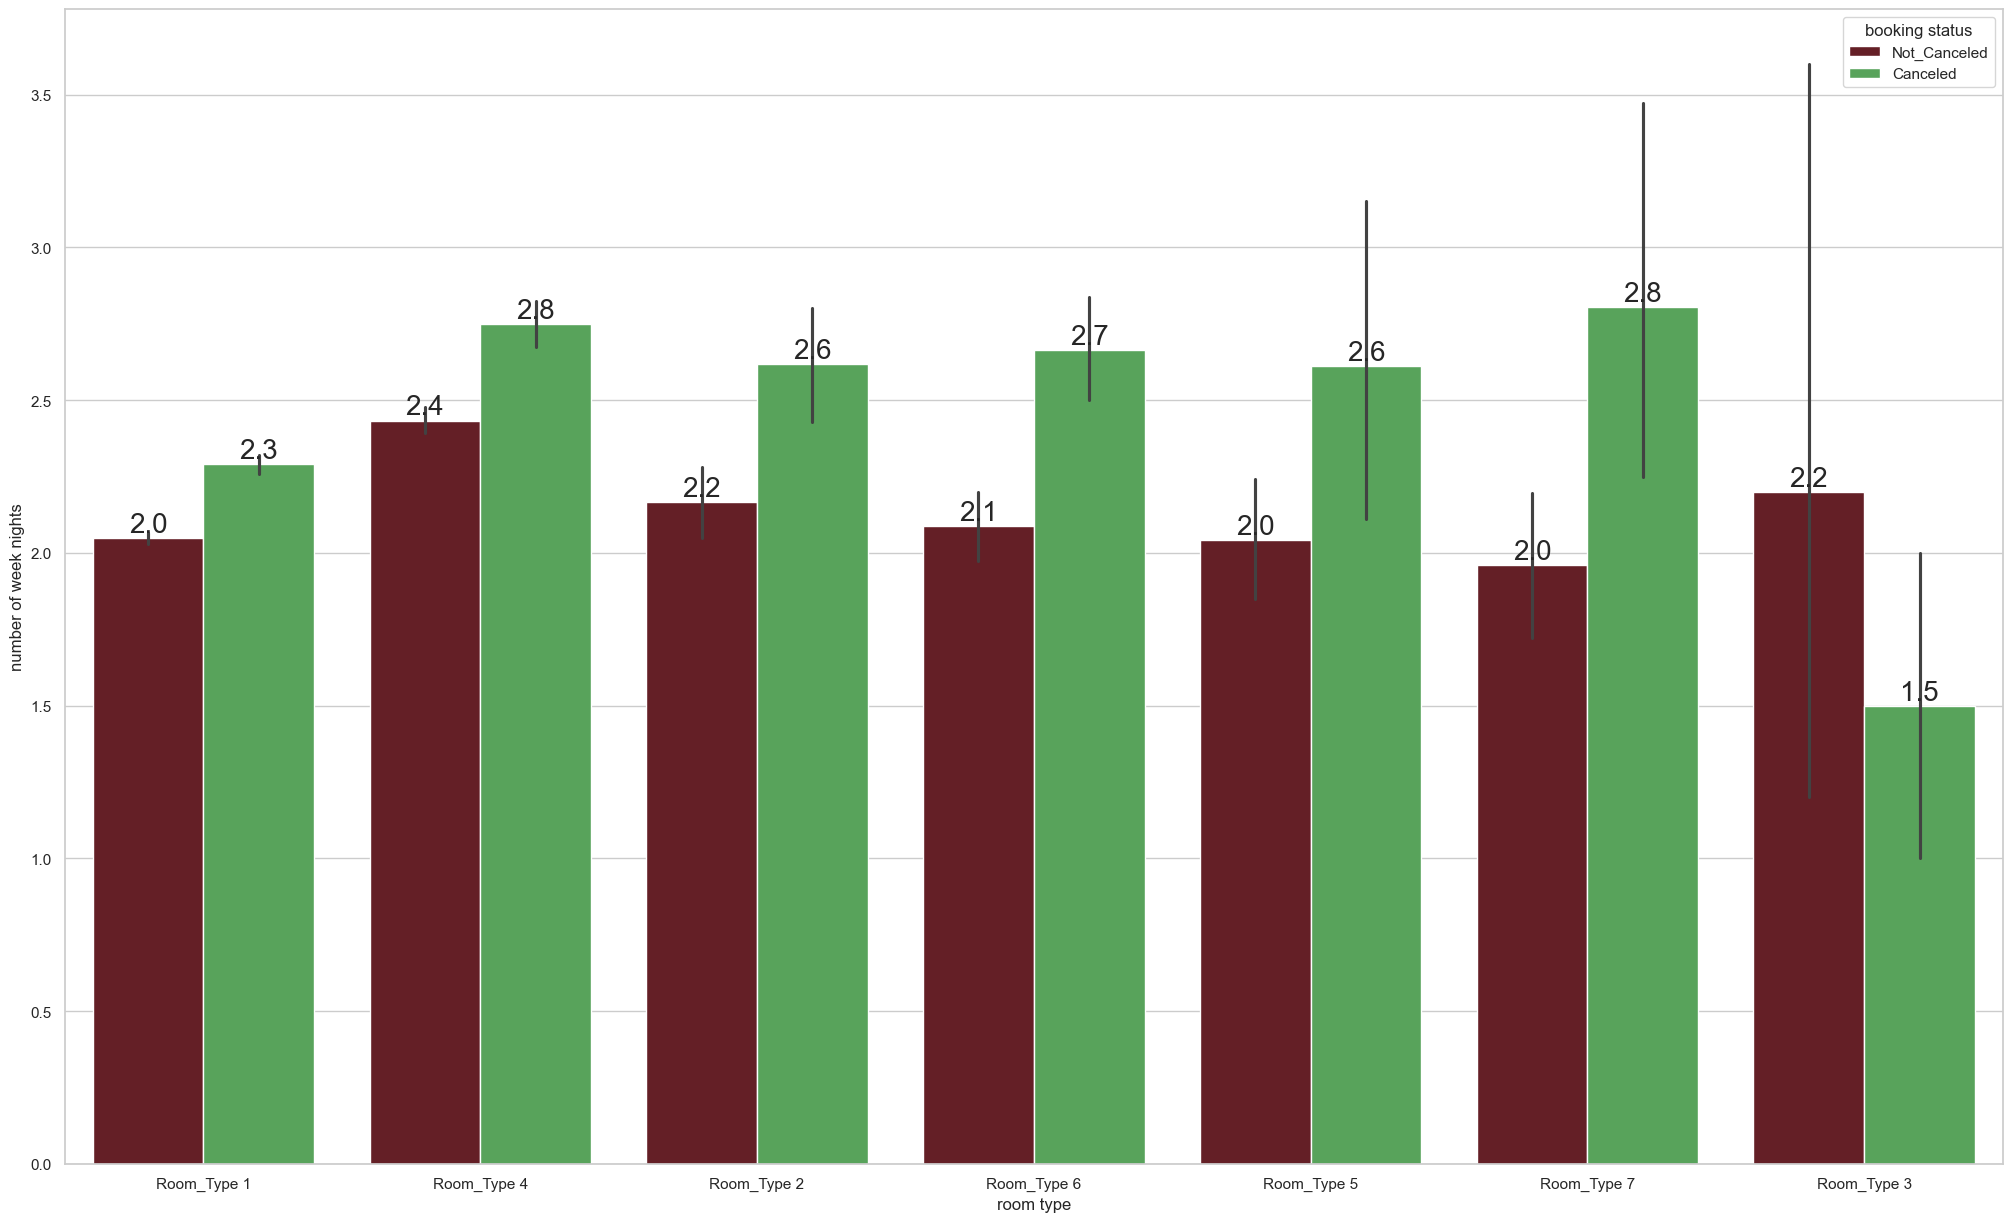

In [73]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='room type', y='number of week nights', hue='booking status', data=data)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.1f', fontsize= 20)
plt.show()

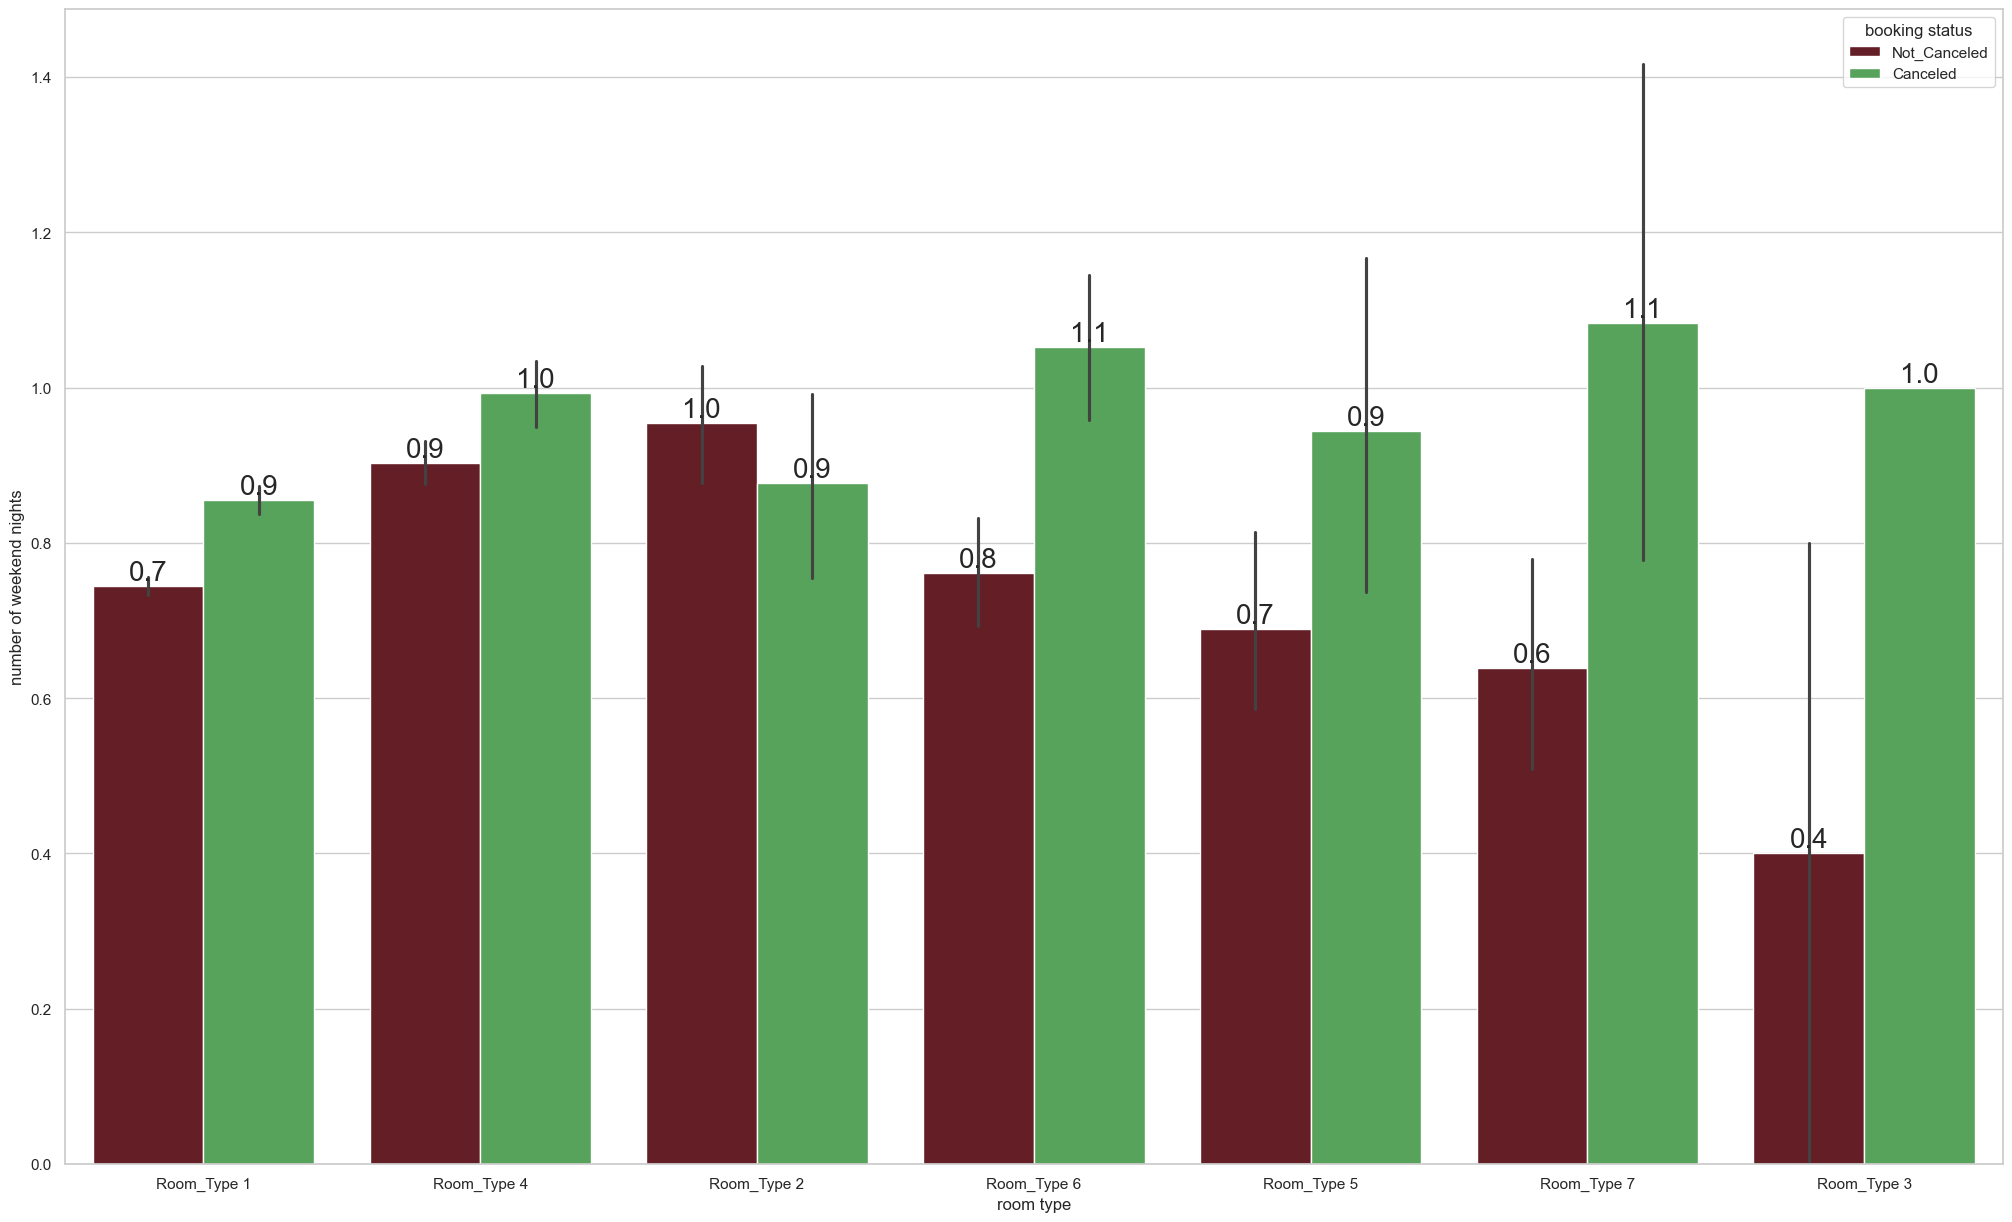

In [74]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='room type', y='number of weekend nights', hue='booking status', data=data)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.1f', fontsize= 20)
plt.show()

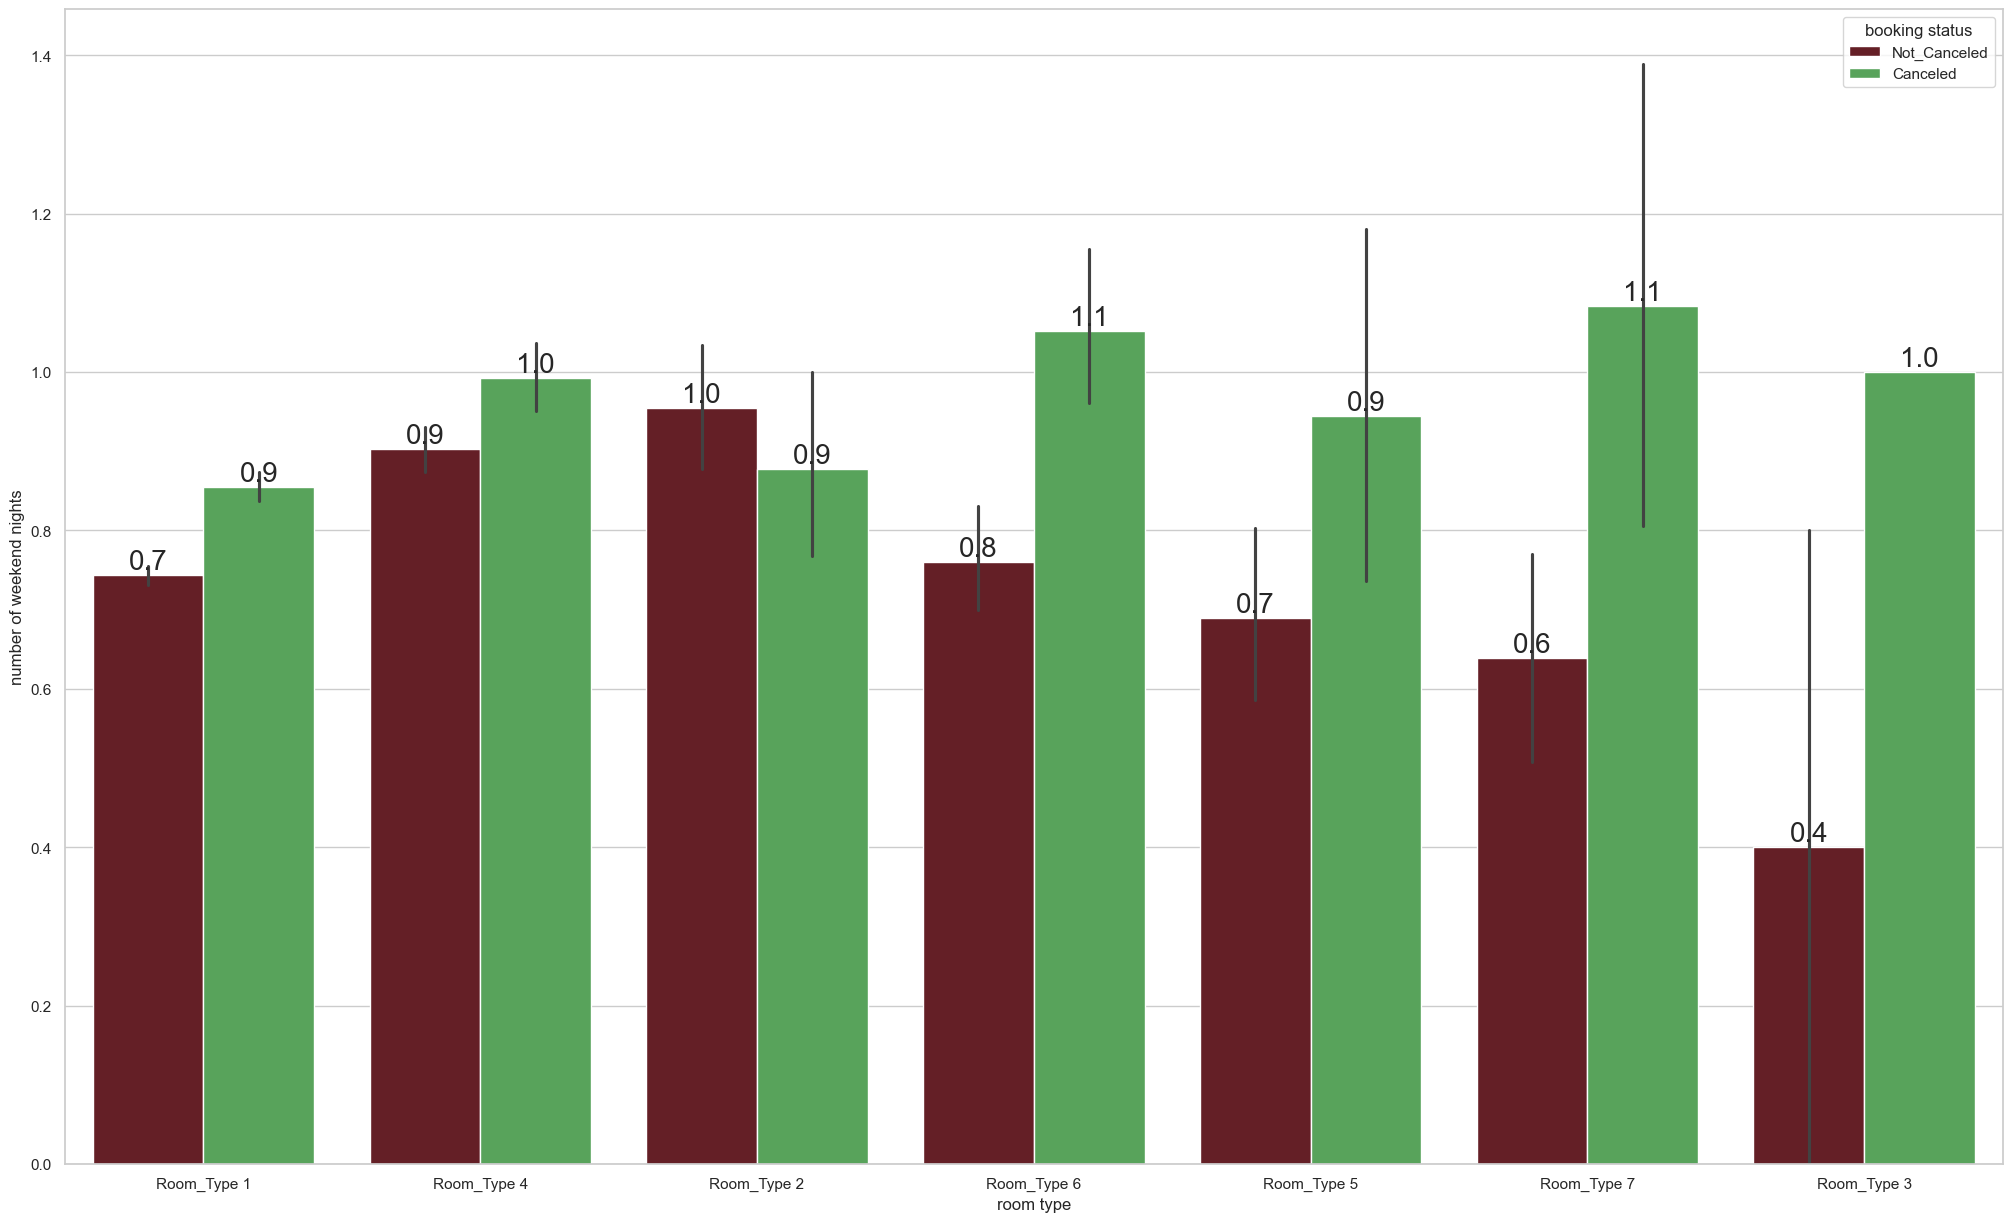

In [75]:
fig, ax = plt.subplots(figsize=(25, 15))
axs = sns.barplot(x='room type', y='number of weekend nights', hue='booking status', data=data)
for container in axs.containers:
    axs.bar_label(container, fmt ='%.1f', fontsize= 20)
plt.show()

In [76]:
# Correlation
ab = data.corr(numeric_only = True)
ab

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
number of adults,1.000000,-0.020027,0.103316,0.105416,0.011467,0.097014,-0.192175,-0.094866,-0.195378,0.296832,0.189317
number of children,-0.020027,1.000000,0.029536,0.024680,0.034198,-0.047058,-0.036371,-0.024658,-0.033107,0.337491,0.124363
number of weekend nights,0.103316,0.029536,1.000000,0.179548,-0.031102,0.046510,-0.067096,-0.031311,-0.065766,-0.004565,0.060432
number of week nights,0.105416,0.024680,0.179548,1.000000,-0.048814,0.149600,-0.099782,-0.040901,-0.105401,0.022751,0.046136
car parking space,0.011467,0.034198,-0.031102,-0.048814,1.000000,-0.066444,0.110916,0.032339,0.118134,0.061310,0.087889
lead time,0.097014,-0.047058,0.046510,0.149600,-0.066444,1.000000,-0.135966,-0.070913,-0.132302,-0.062578,-0.101604
repeated,-0.192175,-0.036371,-0.067096,-0.099782,0.110916,-0.135966,1.000000,0.597876,0.932853,-0.174881,-0.011834
P-C,-0.094866,-0.024658,-0.031311,-0.040901,0.032339,-0.070913,0.597876,1.000000,0.412039,-0.097293,-0.022429
P-not-C,-0.195378,-0.033107,-0.065766,-0.105401,0.118134,-0.132302,0.932853,0.412039,1.000000,-0.174929,0.000184
average price,0.296832,0.337491,-0.004565,0.022751,0.061310,-0.062578,-0.174881,-0.097293,-0.174929,1.000000,0.184468


<Axes: >

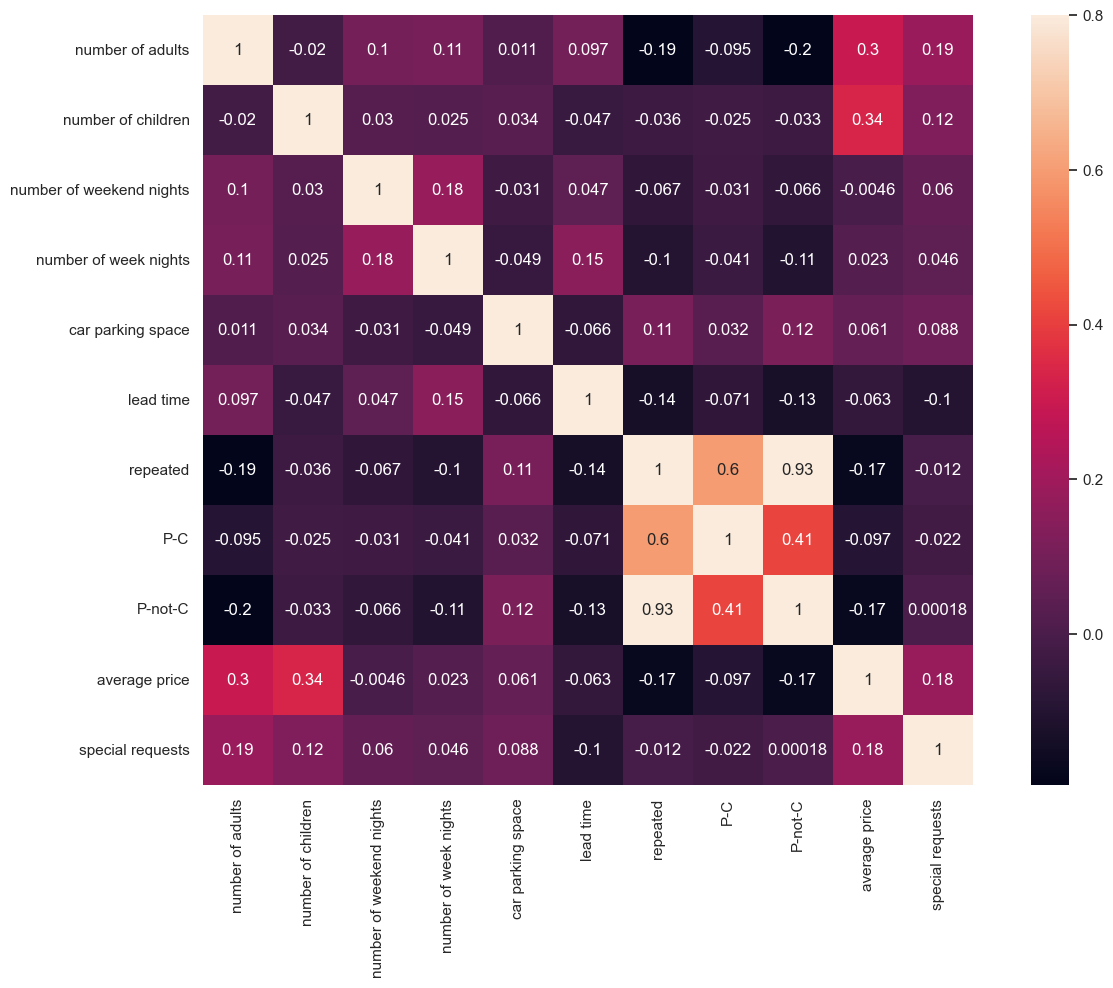

In [77]:
f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(ab, vmax=.8, square=True, annot=True)

In [78]:
data['booking status'].unique()

array(['Not_Canceled', 'Canceled'], dtype=object)

In [79]:
data['booking status'] = data['booking status'].map({
    'Not_Canceled': 0,
    'Canceled': 1
})

In [80]:
data['booking status'].unique()

array([0, 1])

In [81]:
# Correlation
ab = data.corr(numeric_only = True)
ab

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,booking status
number of adults,1.000000,-0.020027,0.103316,0.105416,0.011467,0.097014,-0.192175,-0.094866,-0.195378,0.296832,0.189317,0.086774
number of children,-0.020027,1.000000,0.029536,0.024680,0.034198,-0.047058,-0.036371,-0.024658,-0.033107,0.337491,0.124363,0.033007
number of weekend nights,0.103316,0.029536,1.000000,0.179548,-0.031102,0.046510,-0.067096,-0.031311,-0.065766,-0.004565,0.060432,0.061489
number of week nights,0.105416,0.024680,0.179548,1.000000,-0.048814,0.149600,-0.099782,-0.040901,-0.105401,0.022751,0.046136,0.092824
car parking space,0.011467,0.034198,-0.031102,-0.048814,1.000000,-0.066444,0.110916,0.032339,0.118134,0.061310,0.087889,-0.086179
lead time,0.097014,-0.047058,0.046510,0.149600,-0.066444,1.000000,-0.135966,-0.070913,-0.132302,-0.062578,-0.101604,0.438491
repeated,-0.192175,-0.036371,-0.067096,-0.099782,0.110916,-0.135966,1.000000,0.597876,0.932853,-0.174881,-0.011834,-0.107277
P-C,-0.094866,-0.024658,-0.031311,-0.040901,0.032339,-0.070913,0.597876,1.000000,0.412039,-0.097293,-0.022429,-0.057913
P-not-C,-0.195378,-0.033107,-0.065766,-0.105401,0.118134,-0.132302,0.932853,0.412039,1.000000,-0.174929,0.000184,-0.102840
average price,0.296832,0.337491,-0.004565,0.022751,0.061310,-0.062578,-0.174881,-0.097293,-0.174929,1.000000,0.184468,0.142433


<Axes: >

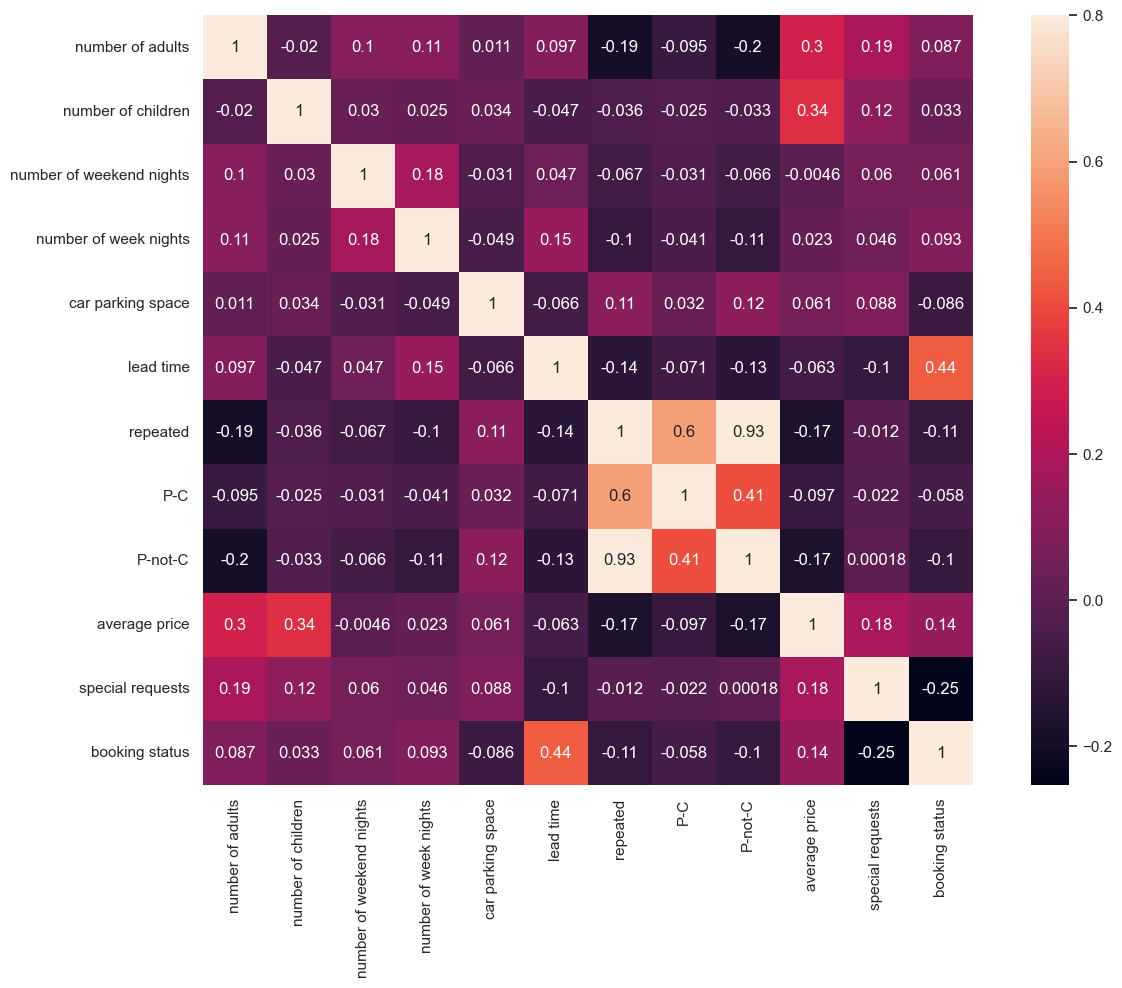

In [82]:
f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(ab, vmax=.8, square=True, annot=True)

In [83]:
data.head()


,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,year,month,day_of_week
0,INN00001,1,1,2,5,Meal Plan 1,False,Room_Type 1,224,Offline,0,False,False,88.00,0,2015-02-10,0,2015.0,Feb,Tue
1,INN00002,1,0,1,3,Not Selected,False,Room_Type 1,5,Online,0,False,False,106.68,1,2018-06-11,0,2018.0,Jun,Mon
2,INN00003,2,1,1,3,Meal Plan 1,False,Room_Type 1,1,Online,0,False,False,50.00,0,2018-02-28,1,2018.0,Feb,Wed
3,INN00004,1,0,0,2,Meal Plan 1,False,Room_Type 1,211,Online,0,False,False,100.00,1,2017-05-20,1,2017.0,May,Sat
4,INN00005,1,0,1,2,Not Selected,False,Room_Type 1,48,Online,0,False,False,77.00,0,2018-11-04,1,2018.0,Nov,Sun


# Machine Learning 
1. Data Cleaning

2. Encoding and Scaling 

3. Check Class Imbalance and Oversampling 

4. Data Splitting and Model Selection
5. Hyperparameter tuning.
6. Model Evaluation

   
Let further clean the data for Machine Learning

## Data cleaning
**Viewing and removing irrelevant features**

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36285 non-null  object        
 1   number of adults          36285 non-null  int64         
 2   number of children        36285 non-null  int64         
 3   number of weekend nights  36285 non-null  int64         
 4   number of week nights     36285 non-null  int64         
 5   type of meal              36285 non-null  object        
 6   car parking space         36285 non-null  bool          
 7   room type                 36285 non-null  object        
 8   lead time                 36285 non-null  int64         
 9   market segment type       36285 non-null  object        
 10  repeated                  36285 non-null  int64         
 11  P-C                       36285 non-null  bool          
 12  P-not-C           

In [85]:
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,lead time,repeated,average price,special requests,date of reservation,booking status
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36248,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,85.239851,0.025630,103.421636,0.619733,2018-05-10 23:23:58.093136384,0.327656
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015-02-10 00:00:00,0.000000
25%,2.000000,0.000000,0.000000,1.000000,17.000000,0.000000,80.300000,0.000000,2018-02-11 00:00:00,0.000000
50%,2.000000,0.000000,1.000000,2.000000,57.000000,0.000000,99.450000,0.000000,2018-06-03 12:00:00,0.000000
75%,2.000000,0.000000,2.000000,3.000000,126.000000,0.000000,120.000000,1.000000,2018-09-13 00:00:00,1.000000
max,4.000000,10.000000,7.000000,17.000000,443.000000,1.000000,540.000000,5.000000,2018-12-31 00:00:00,1.000000
std,0.518813,0.402704,0.870590,1.410946,85.938796,0.158032,35.086469,0.786262,NaN,0.469365


In [86]:
data.drop("Booking_ID", axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   number of adults          36285 non-null  int64         
 1   number of children        36285 non-null  int64         
 2   number of weekend nights  36285 non-null  int64         
 3   number of week nights     36285 non-null  int64         
 4   type of meal              36285 non-null  object        
 5   car parking space         36285 non-null  bool          
 6   room type                 36285 non-null  object        
 7   lead time                 36285 non-null  int64         
 8   market segment type       36285 non-null  object        
 9   repeated                  36285 non-null  int64         
 10  P-C                       36285 non-null  bool          
 11  P-not-C                   36285 non-null  bool          
 12  average price     

In [87]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   number of adults          36285 non-null  int64         
 1   number of children        36285 non-null  int64         
 2   number of weekend nights  36285 non-null  int64         
 3   number of week nights     36285 non-null  int64         
 4   type of meal              36285 non-null  object        
 5   car parking space         36285 non-null  bool          
 6   room type                 36285 non-null  object        
 7   lead time                 36285 non-null  int64         
 8   market segment type       36285 non-null  object        
 9   repeated                  36285 non-null  int64         
 10  P-C                       36285 non-null  bool          
 11  P-not-C                   36285 non-null  bool          
 12  average price     

In [88]:
data.drop("P-not-C", axis=1, inplace=True)
data.drop("date of reservation", axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   number of adults          36285 non-null  int64   
 1   number of children        36285 non-null  int64   
 2   number of weekend nights  36285 non-null  int64   
 3   number of week nights     36285 non-null  int64   
 4   type of meal              36285 non-null  object  
 5   car parking space         36285 non-null  bool    
 6   room type                 36285 non-null  object  
 7   lead time                 36285 non-null  int64   
 8   market segment type       36285 non-null  object  
 9   repeated                  36285 non-null  int64   
 10  P-C                       36285 non-null  bool    
 11  average price             36285 non-null  float64 
 12  special requests          36285 non-null  int64   
 13  booking status            36285 non-null  int6

 Booking ID and P-not-C features have been dropped. P-not-C i basically saying same thing as 

In [89]:
# Lets  check missing values 
data.isnull().sum()

number of adults             0
number of children           0
number of weekend nights     0
number of week nights        0
type of meal                 0
car parking space            0
room type                    0
lead time                    0
market segment type          0
repeated                     0
P-C                          0
average price                0
special requests             0
booking status               0
year                        37
month                       37
day_of_week                 37
dtype: int64

In [90]:
#drop the Null rows 
data.dropna(inplace=True)

In [91]:
data.isnull().sum()

number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
average price               0
special requests            0
booking status              0
year                        0
month                       0
day_of_week                 0
dtype: int64

<Axes: >

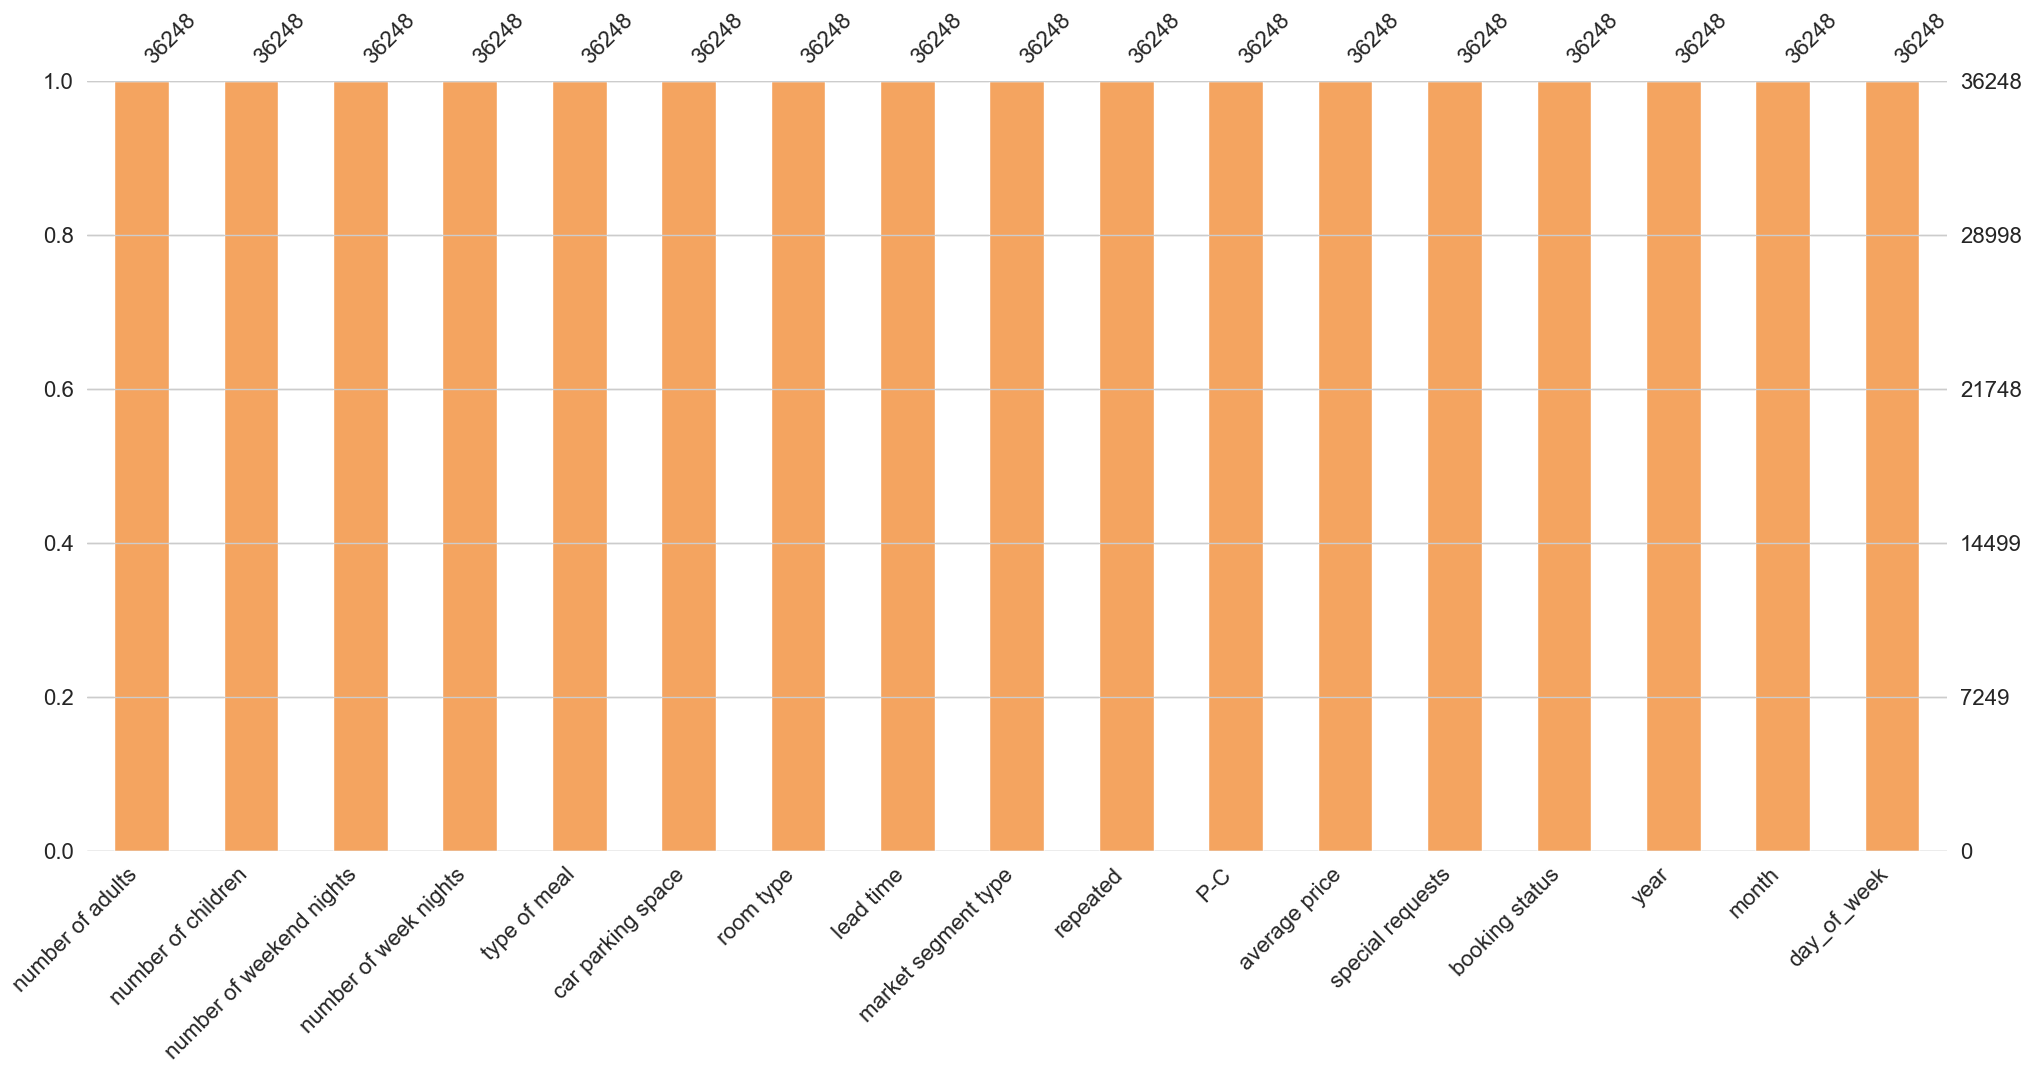

In [92]:
# Lets visualise 
import missingno as msno
msno.bar(data, color='sandybrown')

In [93]:
# Lets check for duplicate data 
data.duplicated().sum()

np.int64(10319)

In [94]:
data = data.drop_duplicates().reset_index(drop=True)

In [95]:
# duplicates dropped 
data.duplicated().sum()

np.int64(0)

In the Initial dataset, there werent any duplicates but after feature selection, duplicate rows emerged due to loss of unique identifiers. These were removed to prevent bias and ensure the model learned generalisable patterns rather than overrepresented observations.

## Checking and handling outliers 
changed booking status back to object data type to prevent it from being affected as its our target variable.

In [96]:
data['booking status'].unique()

array([0, 1])

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25929 entries, 0 to 25928
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   number of adults          25929 non-null  int64   
 1   number of children        25929 non-null  int64   
 2   number of weekend nights  25929 non-null  int64   
 3   number of week nights     25929 non-null  int64   
 4   type of meal              25929 non-null  object  
 5   car parking space         25929 non-null  bool    
 6   room type                 25929 non-null  object  
 7   lead time                 25929 non-null  int64   
 8   market segment type       25929 non-null  object  
 9   repeated                  25929 non-null  int64   
 10  P-C                       25929 non-null  bool    
 11  average price             25929 non-null  float64 
 12  special requests          25929 non-null  int64   
 13  booking status            25929 non-null  int6

In [98]:
data['booking status'] = data['booking status'].astype('bool')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25929 entries, 0 to 25928
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   number of adults          25929 non-null  int64   
 1   number of children        25929 non-null  int64   
 2   number of weekend nights  25929 non-null  int64   
 3   number of week nights     25929 non-null  int64   
 4   type of meal              25929 non-null  object  
 5   car parking space         25929 non-null  bool    
 6   room type                 25929 non-null  object  
 7   lead time                 25929 non-null  int64   
 8   market segment type       25929 non-null  object  
 9   repeated                  25929 non-null  int64   
 10  P-C                       25929 non-null  bool    
 11  average price             25929 non-null  float64 
 12  special requests          25929 non-null  int64   
 13  booking status            25929 non-null  bool

In [99]:
data['repeated'].unique()

array([0, 1])

In [100]:
data['booking status'].unique()

array([False,  True])

In [101]:
data['repeated'] = data['repeated'].astype('bool')

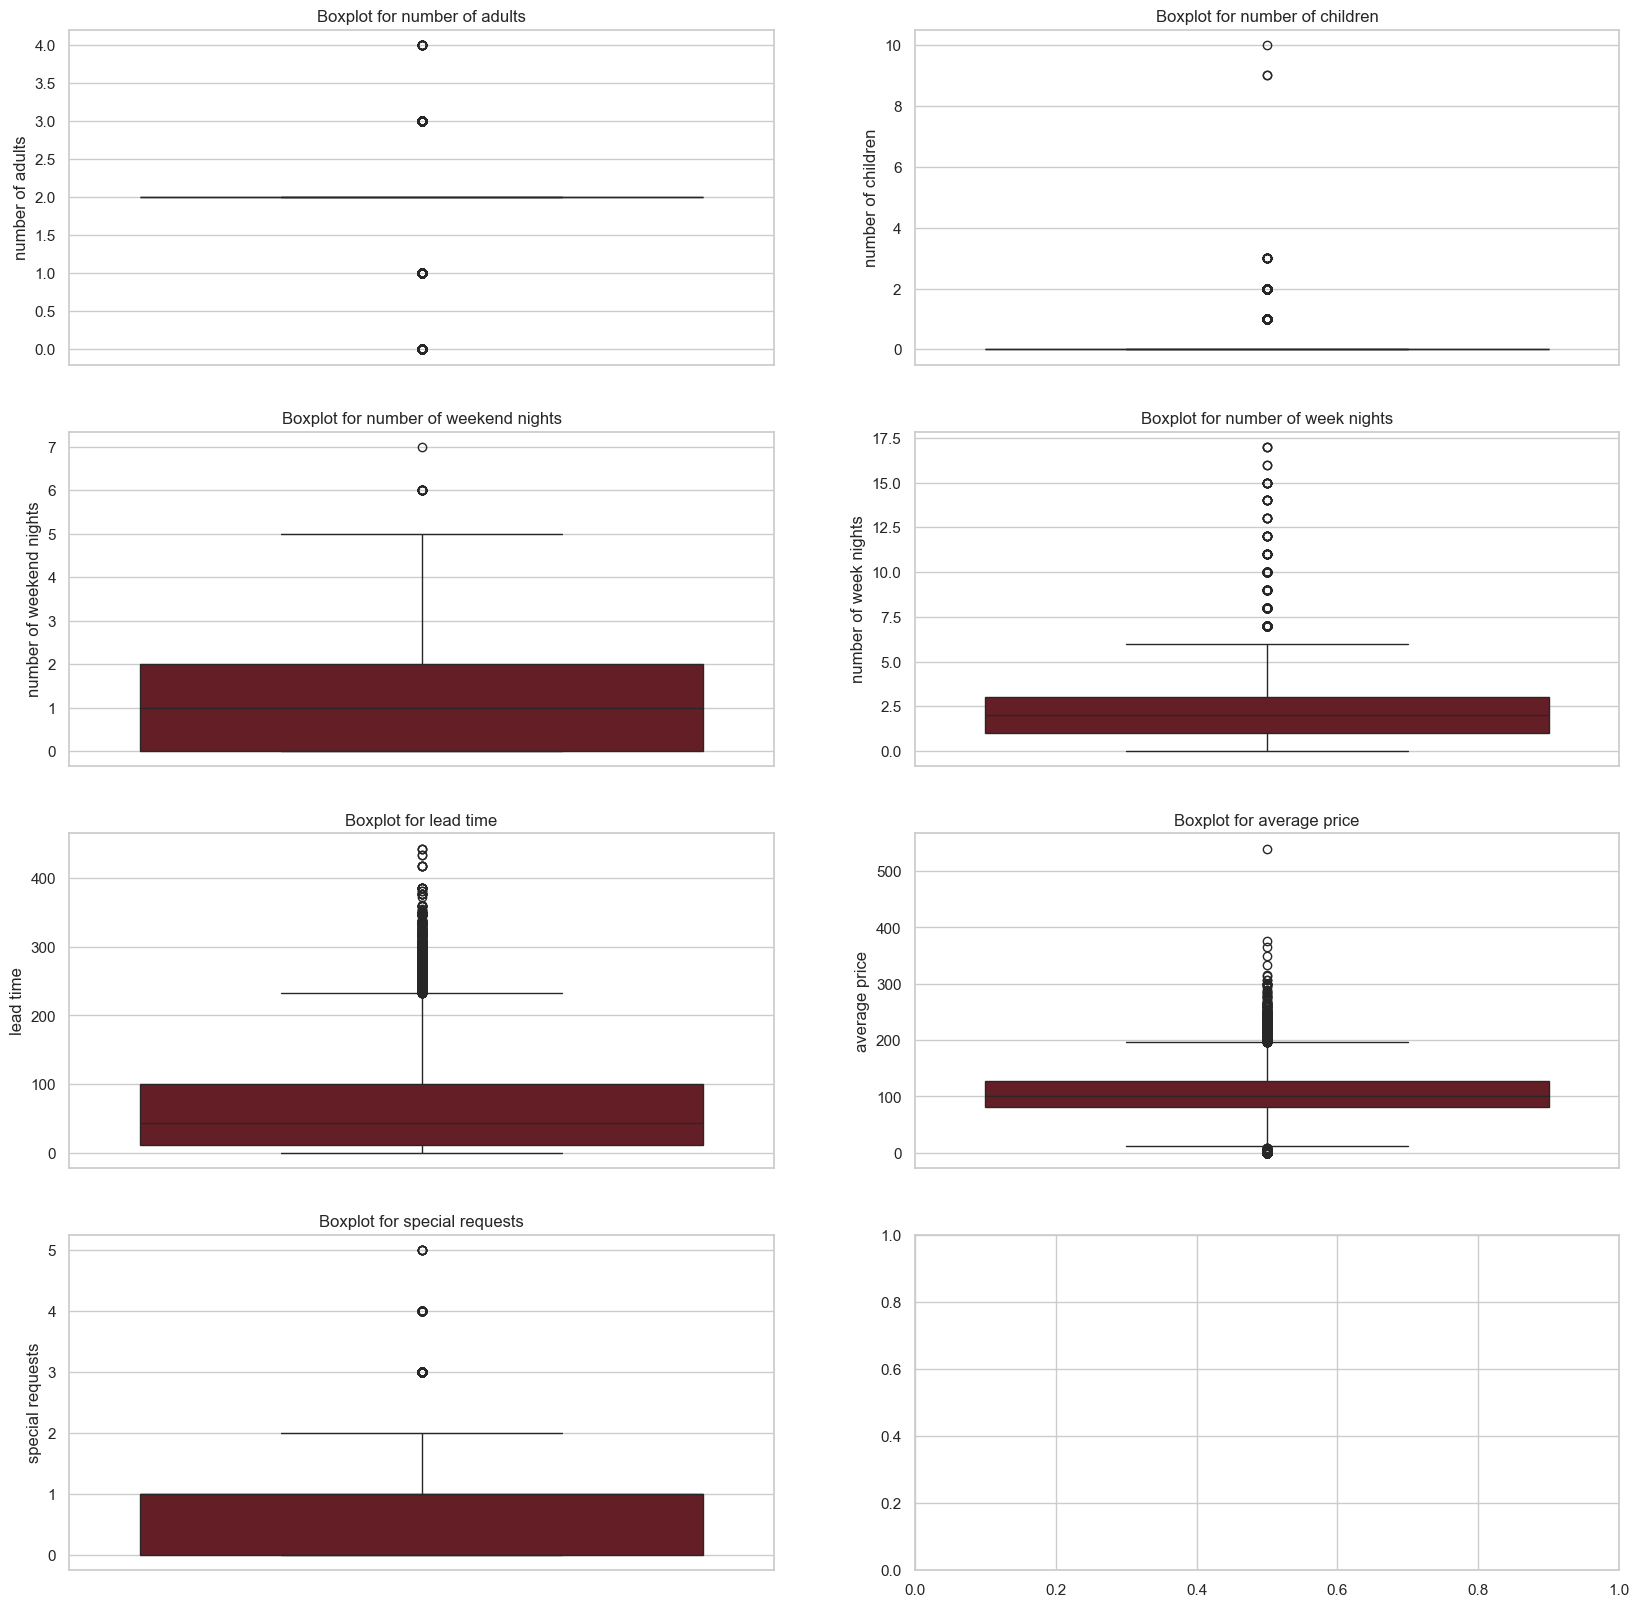

In [102]:
# boxplot
numerical_data = data.select_dtypes(include="number")
fig, ax= plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
ax=ax.flatten()
for idx, col in enumerate(numerical_data):
    sns.boxplot(data[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

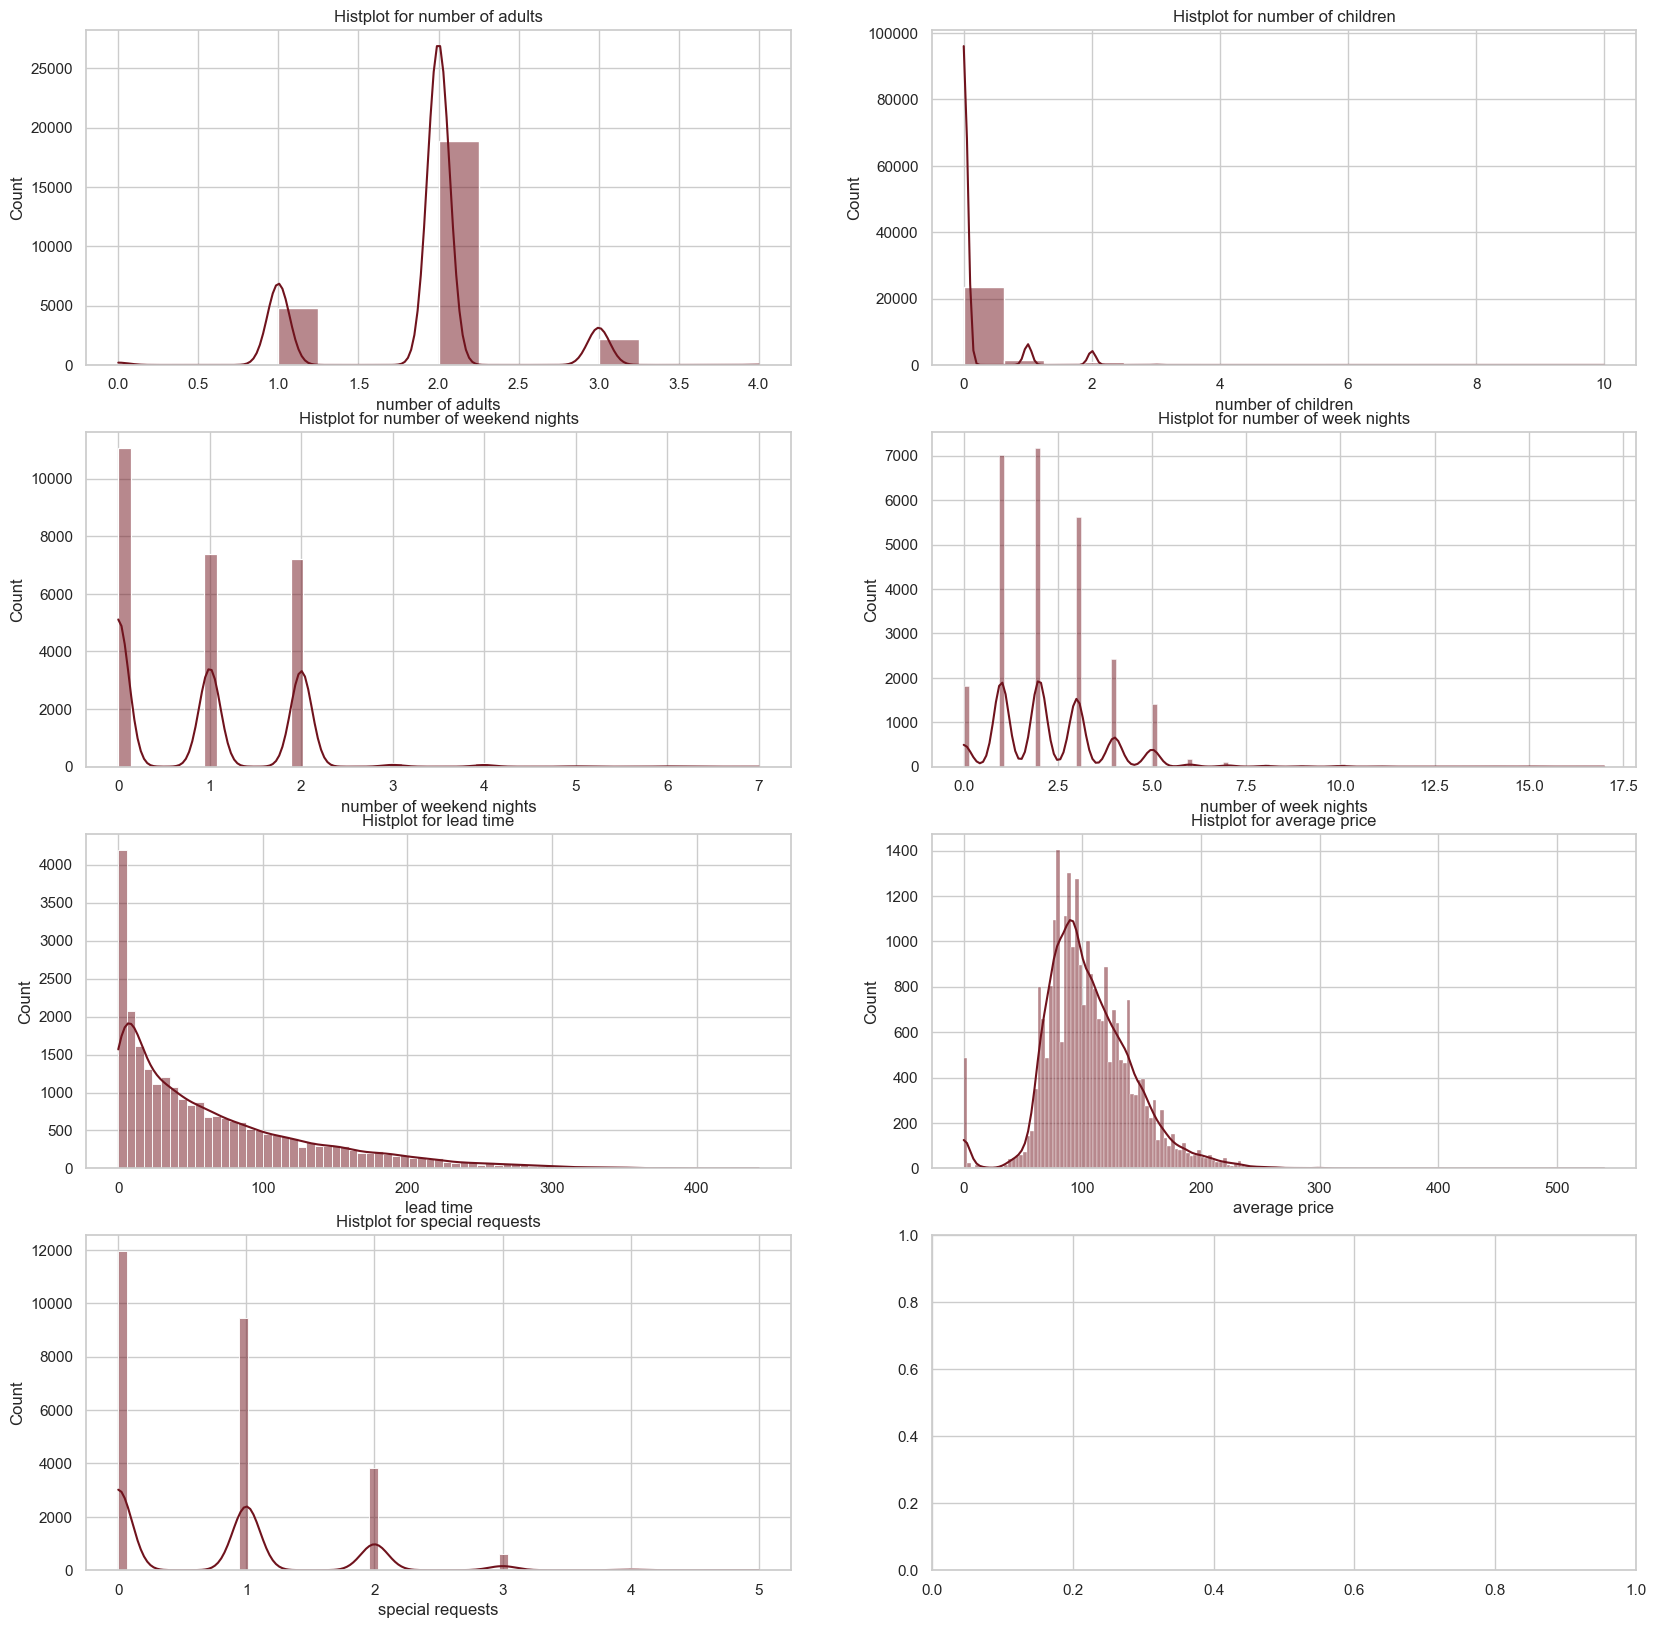

In [103]:
# histogram plot
fig, ax= plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
ax = ax.flatten()
for idx, col in enumerate(numerical_data):
    sns.histplot(data[col], ax=ax[idx], kde=True)
    ax[idx].set_title(f"Histplot for {col}")
plt.show()

In [104]:
# Lets use IQR to remove the outliers on affected columns using IQR
data.info()
affected_columns = ['number of adults', 
                    'number of children', 
                    'number of weekend nights', 
                    'number of week nights', 
                    'lead time',
                    'average price',
                    'special requests']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25929 entries, 0 to 25928
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   number of adults          25929 non-null  int64   
 1   number of children        25929 non-null  int64   
 2   number of weekend nights  25929 non-null  int64   
 3   number of week nights     25929 non-null  int64   
 4   type of meal              25929 non-null  object  
 5   car parking space         25929 non-null  bool    
 6   room type                 25929 non-null  object  
 7   lead time                 25929 non-null  int64   
 8   market segment type       25929 non-null  object  
 9   repeated                  25929 non-null  bool    
 10  P-C                       25929 non-null  bool    
 11  average price             25929 non-null  float64 
 12  special requests          25929 non-null  int64   
 13  booking status            25929 non-null  bool

In [105]:
q1 = data[affected_columns].quantile(0.25)
q3 = data[affected_columns].quantile(0.75)

In [106]:
iqr = q3 - q1

In [107]:
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

In [108]:
data[affected_columns] = data[affected_columns].clip(lower=lower_bound, upper=upper_bound, axis=1)

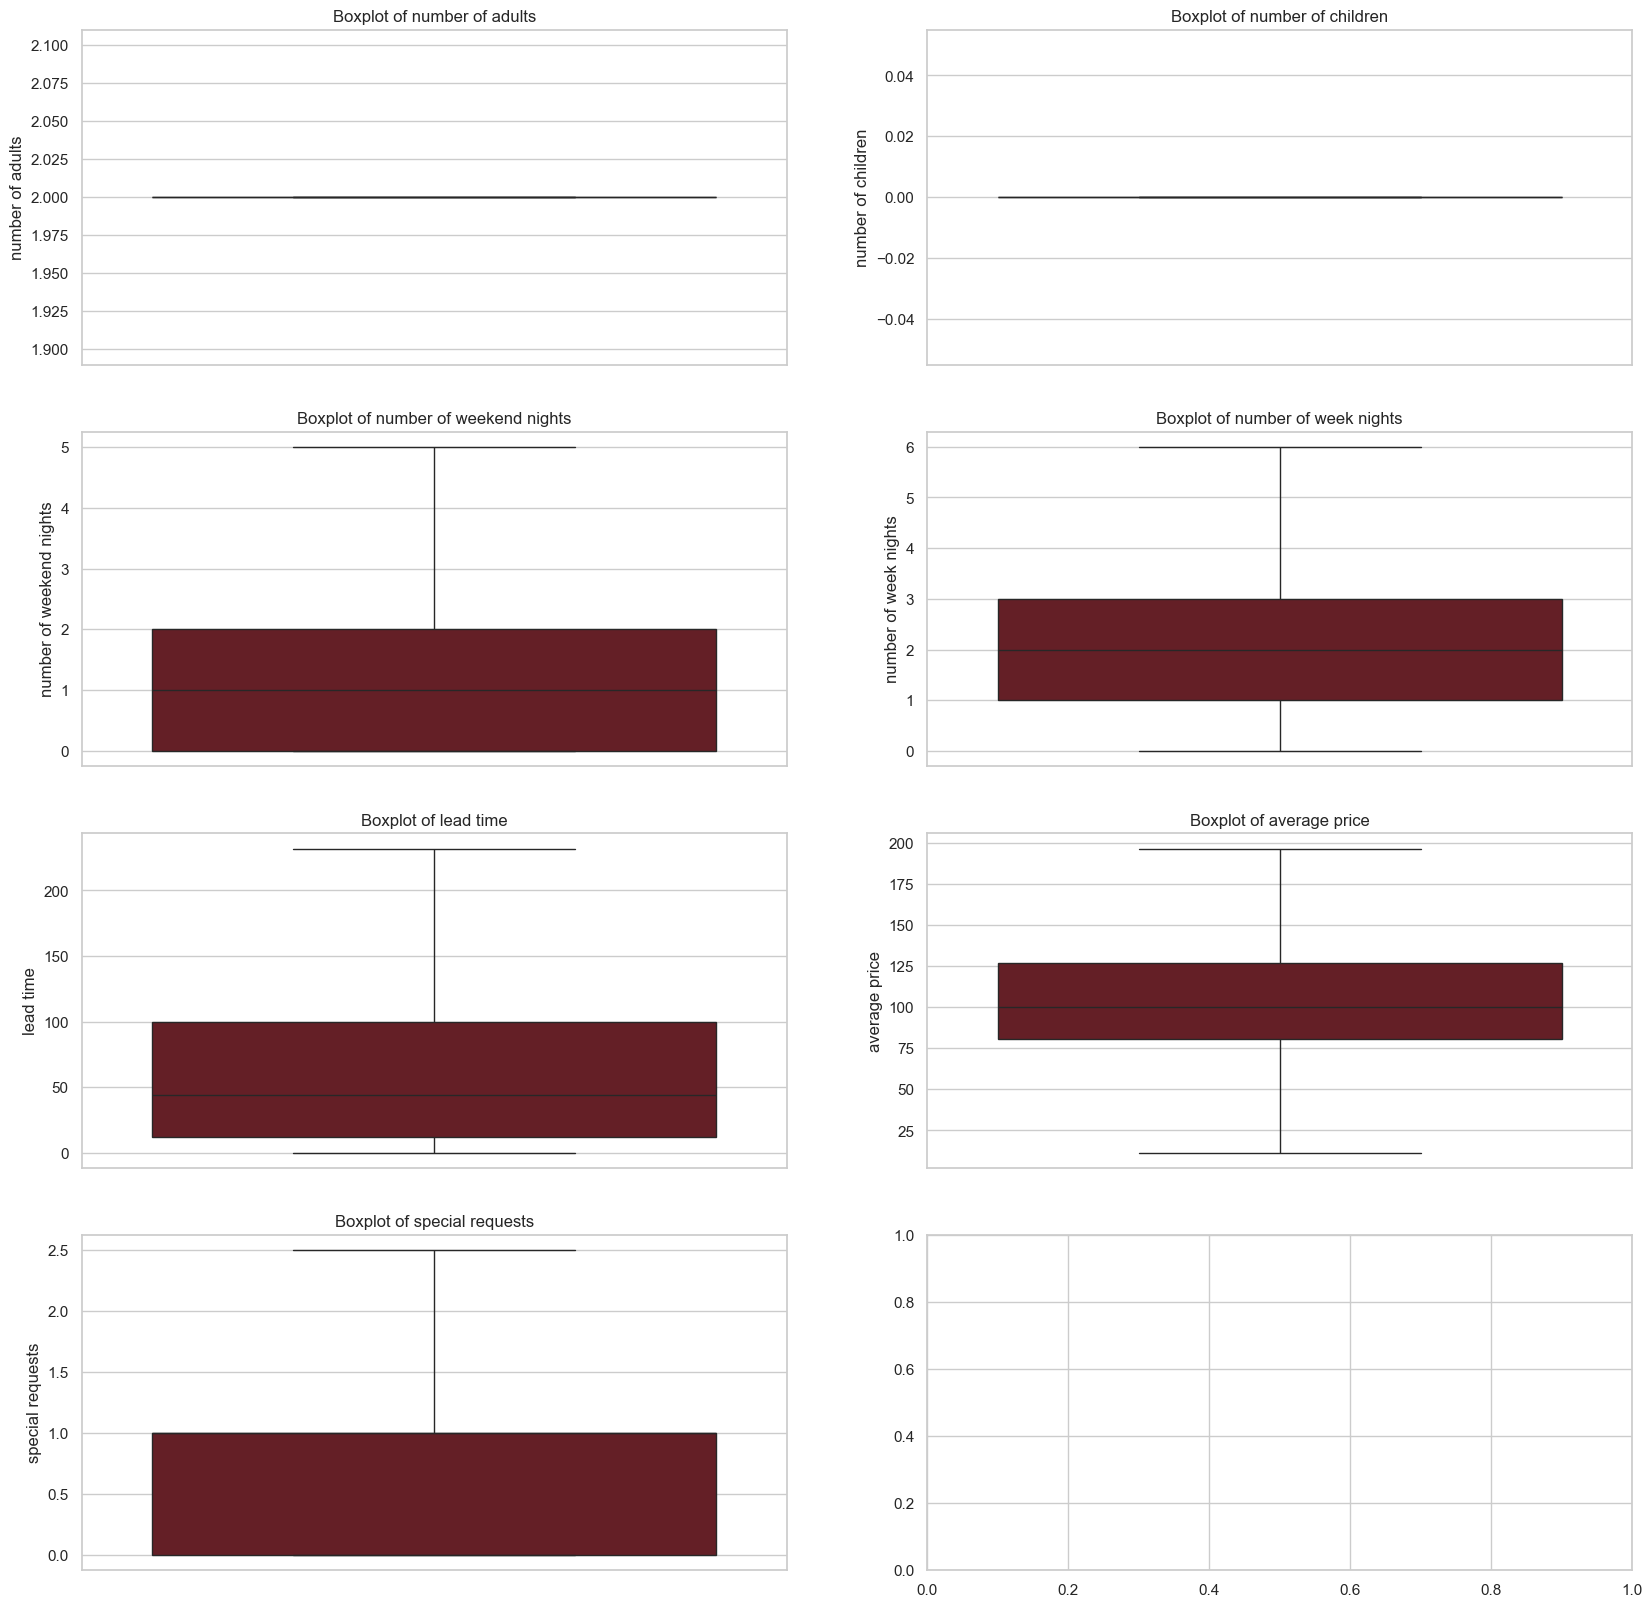

In [109]:
# Lets confirm our data is outlier free
fig, ax =plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
ax= ax.flatten()
for idx, col in enumerate(numerical_data):
    sns.boxplot(data[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot of {col}")
plt.show()

Our data is outlier free

In [110]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,average price,special requests,booking status,year,month,day_of_week
0,2,0,2,5,Meal Plan 1,False,Room_Type 1,224,Offline,False,False,88.00,0.0,False,2015.0,Feb,Tue
1,2,0,1,3,Not Selected,False,Room_Type 1,5,Online,False,False,106.68,1.0,False,2018.0,Jun,Mon
2,2,0,1,3,Meal Plan 1,False,Room_Type 1,1,Online,False,False,50.00,0.0,True,2018.0,Feb,Wed
3,2,0,0,2,Meal Plan 1,False,Room_Type 1,211,Online,False,False,100.00,1.0,True,2017.0,May,Sat
4,2,0,1,2,Not Selected,False,Room_Type 1,48,Online,False,False,77.00,0.0,True,2018.0,Nov,Sun


In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25929 entries, 0 to 25928
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   number of adults          25929 non-null  int64   
 1   number of children        25929 non-null  int64   
 2   number of weekend nights  25929 non-null  int64   
 3   number of week nights     25929 non-null  int64   
 4   type of meal              25929 non-null  object  
 5   car parking space         25929 non-null  bool    
 6   room type                 25929 non-null  object  
 7   lead time                 25929 non-null  int64   
 8   market segment type       25929 non-null  object  
 9   repeated                  25929 non-null  bool    
 10  P-C                       25929 non-null  bool    
 11  average price             25929 non-null  float64 
 12  special requests          25929 non-null  float64 
 13  booking status            25929 non-null  bool

## Encode categorical variables
- Label Encoding for binary categorical variables - car parking space, P-C, repeated, booking status
- One hot encoding for type of meal, room type, market segment type, year, month, day_of_week, 

In [112]:
from sklearn.preprocessing import LabelEncoder

In [113]:
# Label encoding for binary categories
label_enc = LabelEncoder() # Initialise Encoder
data['car parking space'] = label_enc.fit_transform(data['car parking space'])
data['P-C'] = label_enc.fit_transform(data['P-C'])
data['repeated'] = label_enc.fit_transform(data['repeated'])
data['booking status'] = label_enc.fit_transform(data['booking status'])

In [114]:
# One-Hot Encoding for Dobject categories
data = pd.get_dummies(data, columns=['type of meal'])
data = pd.get_dummies(data, columns=['room type'])
data = pd.get_dummies(data, columns=['market segment type'])
data = pd.get_dummies(data, columns=['year'])
data = pd.get_dummies(data, columns=['month'])
data = pd.get_dummies(data, columns=['day_of_week'])

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25929 entries, 0 to 25928
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   number of adults                   25929 non-null  int64  
 1   number of children                 25929 non-null  int64  
 2   number of weekend nights           25929 non-null  int64  
 3   number of week nights              25929 non-null  int64  
 4   car parking space                  25929 non-null  int64  
 5   lead time                          25929 non-null  int64  
 6   repeated                           25929 non-null  int64  
 7   P-C                                25929 non-null  int64  
 8   average price                      25929 non-null  float64
 9   special requests                   25929 non-null  float64
 10  booking status                     25929 non-null  int64  
 11  type of meal_Meal Plan 1           25929 non-null  boo

In [116]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,average price,special requests,...,month_Nov,month_Oct,month_Sep,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed
0,2,0,2,5,0,224,0,0,88.00,0.0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,1,3,0,5,0,0,106.68,1.0,...,False,False,False,False,True,False,False,False,False,False
2,2,0,1,3,0,1,0,0,50.00,0.0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,0,0,100.00,1.0,...,False,False,False,False,False,True,False,False,False,False
4,2,0,1,2,0,48,0,0,77.00,0.0,...,True,False,False,False,False,False,True,False,False,False


## Scale the Numerical features 


In [117]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [118]:
# Initialise Scaler
scaler = StandardScaler()
# put affected columns in list
num_cols_to_scale = ['number of adults', 
                    'number of children', 
                    'number of weekend nights', 
                    'number of week nights', 
                    'lead time',
                    'average price',
                    'special requests']
# scale the columns
data[num_cols_to_scale] = scaler.fit_transform(data[num_cols_to_scale])

In [119]:
# verify scaling 
data[num_cols_to_scale].describe()

,number of adults,number of children,number of weekend nights,number of week nights,lead time,average price,special requests
count,25929.0,25929.0,2.592900e+04,2.592900e+04,2.592900e+04,2.592900e+04,2.592900e+04
mean,0.0,0.0,1.104357e-16,-9.700803e-17,-9.673400e-17,-9.536383e-17,-8.988315e-17
std,0.0,0.0,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,0.0,0.0,-9.981619e-01,-1.631000e+00,-1.015106e+00,-2.648718e+00,-9.434335e-01
25%,0.0,0.0,-9.981619e-01,-8.995257e-01,-8.279993e-01,-6.953150e-01,-9.434335e-01
50%,0.0,0.0,1.337081e-01,-1.680510e-01,-3.290475e-01,-1.532897e-01,3.548171e-01
75%,0.0,0.0,1.265578e+00,5.634237e-01,5.441181e-01,6.069535e-01,3.548171e-01
max,0.0,0.0,4.661188e+00,2.757848e+00,2.602294e+00,2.560356e+00,2.302193e+00


## Check and handle class imbalance 
Check and handle class imbalance for the target variable Booking Status

In [120]:
# check class imbalance 
data['booking status'].value_counts()

booking status
0    18493
1     7436
Name: count, dtype: int64

<Axes: xlabel='booking status', ylabel='count'>

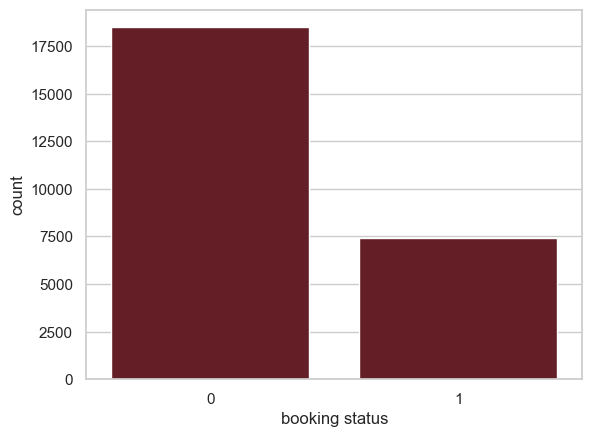

In [121]:
sns.countplot(x=data['booking status'])

## Oversampling with SMOTE
We need to handle class imbalance. We will use Oversampling

In [122]:
pip install --upgrade imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [123]:
from imblearn.over_sampling import SMOTE

In [124]:
# Separate features and target
X = data.drop('booking status', axis=1)
y = data['booking status']

In [125]:
# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [126]:
y_resampled.value_counts()

booking status
0    18493
1    18493
Name: count, dtype: int64

<Axes: xlabel='booking status', ylabel='count'>

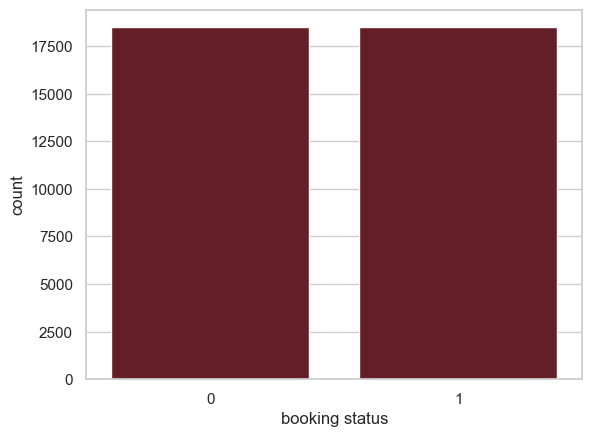

In [127]:
sns.countplot(x=y_resampled)

## Final Dataset ready for Model Training 
Save Dataset and proceed


In [128]:
# Save the cleaned dataset for future use
data.to_csv('cleaned_ML_HotelHaven.csv', index=False)

## Data Splitting 
Data will now be split into train and test data

## Data Split
Data will now be split between training and test data using 80/20 split

In [129]:
from sklearn.model_selection import train_test_split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
# stratify to maintain class proportions

In [131]:
print("Training set size:",  len(X_train))
print("Testing set size", len(X_test))

Training set size: 29588
Testing set size 7398


In [132]:
y_train.value_counts(normalize=True)*100

booking status
1    50.0
0    50.0
Name: proportion, dtype: float64

In [133]:
y_test.value_counts(normalize=True)*100

booking status
0    50.0
1    50.0
Name: proportion, dtype: float64

## Model Training
We will first use the Logistic Regresison and then Random Forest Classifier then test other models 

**Logistic Regression**

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [135]:
# Train logistic regression model
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [136]:
# Predict on the test set
y_pred = logreg.predict(X_test)

In [137]:
# Evaluate performance
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      3699
           1       0.84      0.82      0.83      3699

    accuracy                           0.83      7398
   macro avg       0.83      0.83      0.83      7398
weighted avg       0.83      0.83      0.83      7398



**Random Forest Classifier**

In [138]:
from sklearn.ensemble import RandomForestClassifier

In [139]:
# Train random forest model
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [140]:
# Predict on the test
y_pred_rf = rf.predict(X_test)

In [141]:
# Evaluate Performance
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3699
           1       0.90      0.90      0.90      3699

    accuracy                           0.90      7398
   macro avg       0.90      0.90      0.90      7398
weighted avg       0.90      0.90      0.90      7398



**Train with multiple Classification models at once**
Logistic Regression

Random Forest CLassifier.

Gradient Boost Classifier.

AdaBoost Classifier.

Support Vector Machine.

K Nearest neighbors.

Decision tree Classifier.

XGBoost Classifier

In [142]:
!pip install xgboost

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [144]:
# Define the models
class_weights='balanced'
models = {
    'Logistic Regression': LogisticRegression(random_state=41, class_weight=class_weights),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight=class_weights), 
    'Support Vector Machine': SVC(random_state=42, class_weight=class_weights),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight=class_weights),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss')

}

Training Logistic Regression.....
Logistic Regression Accuracy: 0.8282
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      3699
           1       0.84      0.82      0.83      3699

    accuracy                           0.83      7398
   macro avg       0.83      0.83      0.83      7398
weighted avg       0.83      0.83      0.83      7398



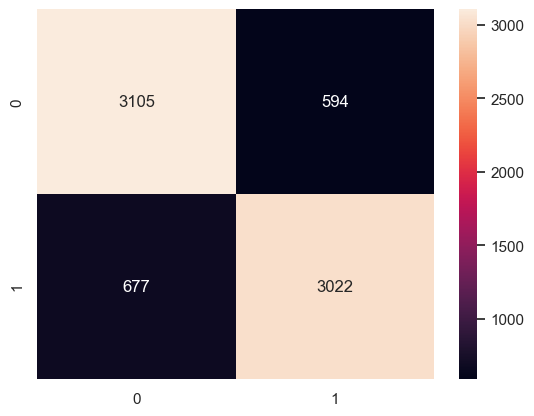

Training Random Forest.....
Random Forest Accuracy: 0.8962
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3699
           1       0.90      0.90      0.90      3699

    accuracy                           0.90      7398
   macro avg       0.90      0.90      0.90      7398
weighted avg       0.90      0.90      0.90      7398



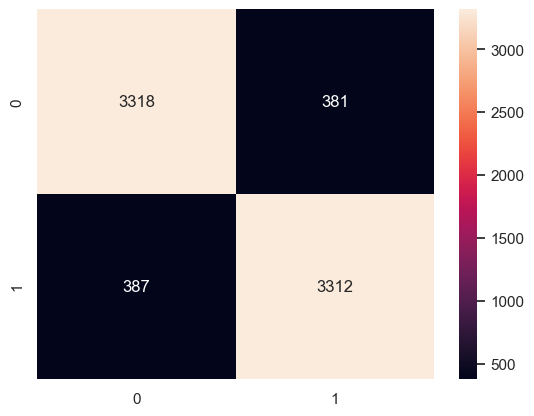

Training Support Vector Machine.....
Support Vector Machine Accuracy: 0.8587
Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      3699
           1       0.87      0.84      0.86      3699

    accuracy                           0.86      7398
   macro avg       0.86      0.86      0.86      7398
weighted avg       0.86      0.86      0.86      7398



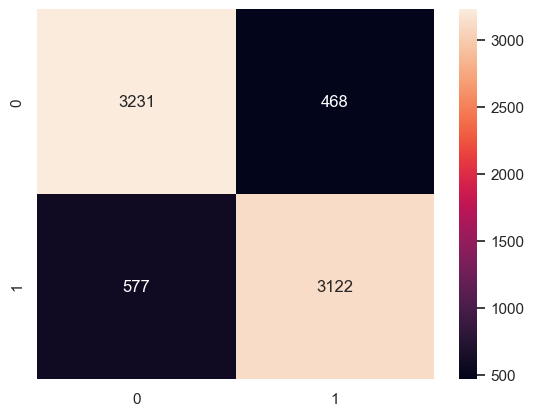

Training k-Nearest Neighbors.....
k-Nearest Neighbors Accuracy: 0.8405
k-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      3699
           1       0.80      0.90      0.85      3699

    accuracy                           0.84      7398
   macro avg       0.85      0.84      0.84      7398
weighted avg       0.85      0.84      0.84      7398



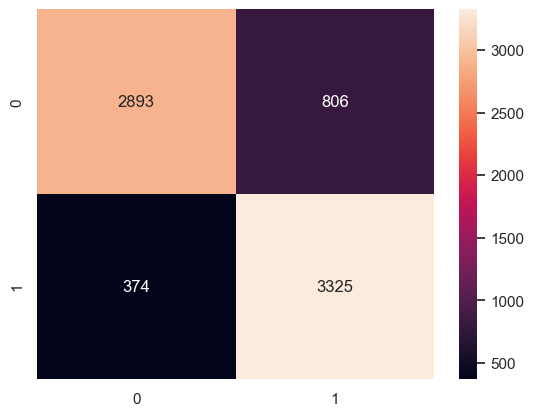

Training Decision Tree.....
Decision Tree Accuracy: 0.8312
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      3699
           1       0.83      0.84      0.83      3699

    accuracy                           0.83      7398
   macro avg       0.83      0.83      0.83      7398
weighted avg       0.83      0.83      0.83      7398



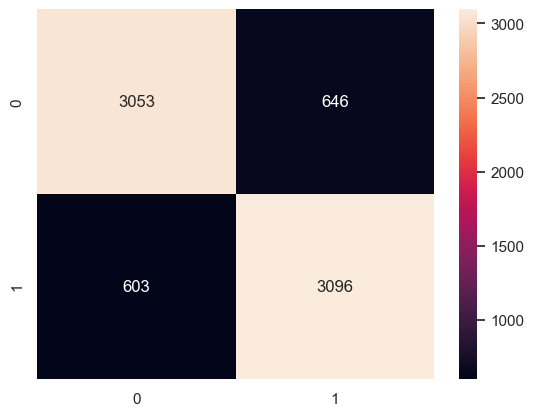

Training Gradient Boosting.....
Gradient Boosting Accuracy: 0.8383
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      3699
           1       0.86      0.81      0.83      3699

    accuracy                           0.84      7398
   macro avg       0.84      0.84      0.84      7398
weighted avg       0.84      0.84      0.84      7398



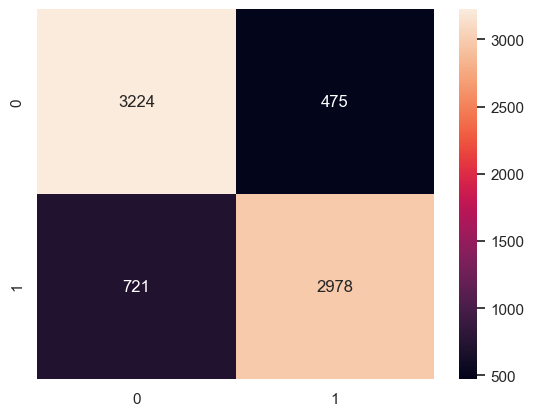

Training AdaBoost.....
AdaBoost Accuracy: 0.8067
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3699
           1       0.81      0.80      0.81      3699

    accuracy                           0.81      7398
   macro avg       0.81      0.81      0.81      7398
weighted avg       0.81      0.81      0.81      7398



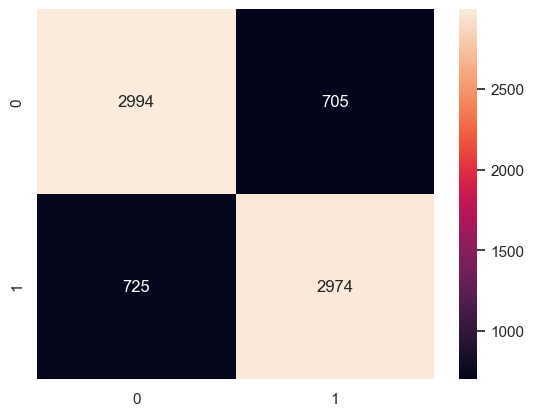

Training XGBoost.....
XGBoost Accuracy: 0.8921
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3699
           1       0.90      0.88      0.89      3699

    accuracy                           0.89      7398
   macro avg       0.89      0.89      0.89      7398
weighted avg       0.89      0.89      0.89      7398



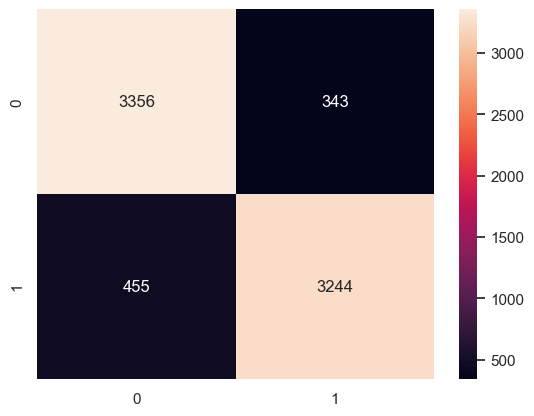

In [145]:
from sklearn.metrics import classification_report, accuracy_score

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}.....")
    #Train the model
    model.fit(X_train, y_train)

    # Make Predictions
    y_pred = model.predict(X_test)

    # Evaluate Model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} Classification Report:\n{report}")


    sns.heatmap(matrix, annot=True, fmt="g")
    plt.show()

## Hyperparameter Tuning 
Otimise parameters for Random Forest Model. It had the best scores 

In [146]:
from sklearn.model_selection import GridSearchCV

In [147]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [148]:
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [149]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [150]:
# Best Parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [151]:
# Train best model
best_rf = grid_search.best_estimator_

In [152]:
# Predict on the test set
y_pred_best_rf = best_rf.predict(X_test)

In [153]:
# Evaluate Performance
print("Tuned Random Forst Forest Classification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forst Forest Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      3699
           1       0.90      0.90      0.90      3699

    accuracy                           0.90      7398
   macro avg       0.90      0.90      0.90      7398
weighted avg       0.90      0.90      0.90      7398



## Model Evaluation
We will perform a detailed evaluation using metrics like precision, recall, F1-score and AUC-ROC. Confusion Matrices and AUC curves will help visualise

In [154]:
from sklearn.metrics import confusion_matrix

In [155]:
conf_matrix = confusion_matrix(y_test, y_pred_best_rf)

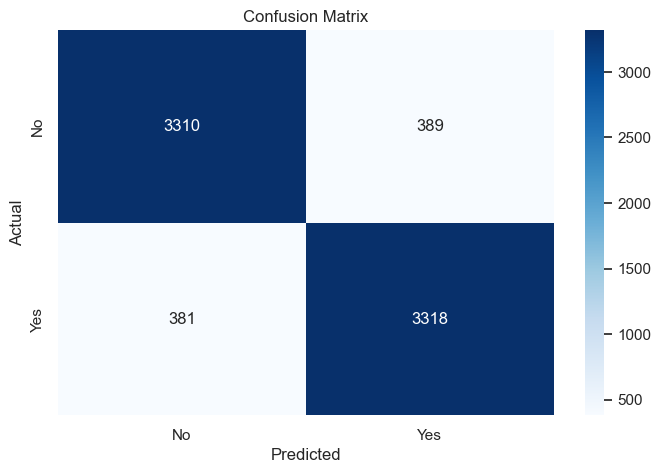

In [156]:
# Plot the confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d',
            cmap='Blues', 
            xticklabels=['No', 'Yes'], 
            yticklabels=['No', 'Yes']
           )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve and AUC Score
to evaluate model's ability to distinguish between classes

In [157]:
from sklearn.metrics import roc_curve, roc_auc_score

In [158]:
# Compute probabilities for ROC
y_probs = best_rf.predict_proba(X_test)[:, 1] # probabilities for the positive class

In [159]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

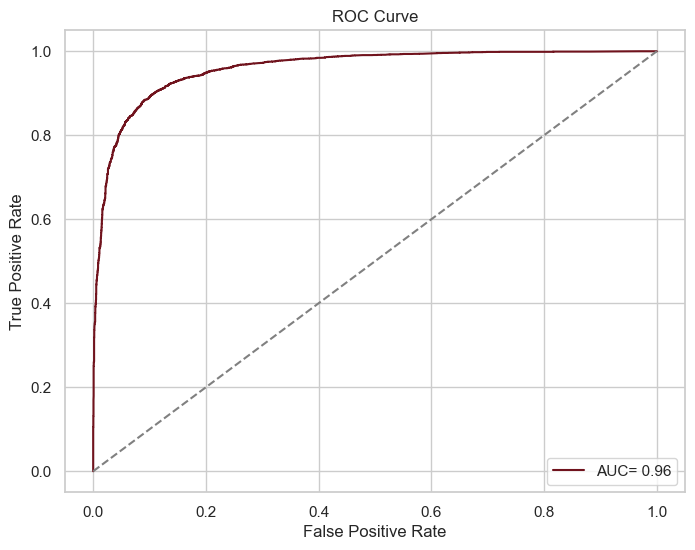

In [160]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC= {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Saving the Model 

In [161]:
# save_model(final_model, 'final_model_booking_status_prediction')

In [162]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,average price,special requests,...,month_Nov,month_Oct,month_Sep,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed
0,0.0,0.0,1.265578,2.026373,0,2.477556,0,0,-0.491176,-0.943433,...,False,False,False,False,False,False,False,False,True,False
1,0.0,0.0,0.133708,0.563424,0,-0.937145,0,0,0.034800,0.354817,...,False,False,False,False,True,False,False,False,False,False
2,0.0,0.0,0.133708,0.563424,0,-0.999514,0,0,-1.561147,-0.943433,...,False,False,False,False,False,False,False,False,False,True
3,0.0,0.0,-0.998162,-0.168051,0,2.274857,0,0,-0.153290,0.354817,...,False,False,False,False,False,True,False,False,False,False
4,0.0,0.0,0.133708,-0.168051,0,-0.266679,0,0,-0.800904,-0.943433,...,True,False,False,False,False,False,True,False,False,False


In [163]:
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [165]:
import joblib

In [167]:
# Save your final trained model
joblib.dump(best_rf, "hotel_booking_rf.pkl")

['hotel_booking_rf.pkl']

In [168]:
print("Model saved successfully!")

Model saved successfully!
